# G6 Smart City IDS — Best Notebook (mMTC / URLLC / eMBB / G6)

# 📌 Library Imports

## 1. Import Required Libraries

In this cell, we import all necessary Python libraries used throughout the notebook.

These include:

- **pandas / numpy** → Data manipulation and numerical computation  
- **matplotlib / seaborn** → Data visualization  
- **sklearn modules** → Preprocessing, modeling, and evaluation  

This step initializes the environment for data analysis, preprocessing, and machine learning experiments.


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)

USE_XGBOOST = True
try:
    from xgboost import XGBClassifier
except Exception:
    USE_XGBOOST = False

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)


# 📌 Dataset Loading

## 2. Dataset Loading

This cell loads the four datasets:

- **mMTC**
- **URLLC**
- **eMBB**
- **G6**

The datasets are loaded dynamically from CSV files located in the current directory.

A dictionary (`datasets`) is used to store them for structured access.


In [2]:
# Imputation strategy per report Section 5:
#   "median" -> SimpleImputer(median) [RECOMMENDED for all G6 datasets]
#   "knn"    -> KNNImputer            [only if missingness > 10% AND features are correlated]
NUM_IMPUTER = "median"
KNN_K = 5

def load_dataset(name, filename):
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        print(f"Loaded {name}: {df.shape} from {filename}")
        return df
    else:
        print(f"Skipped {name}: file not found ({filename})")
        return None

datasets = {}
datasets["mMTC"]  = load_dataset("mMTC",  "mMTC.csv")
datasets["URLLC"] = load_dataset("URLLC", "URLLC.csv")
datasets["eMBB"]  = load_dataset("eMBB",  "eMBB.csv")
datasets["G6"]    = load_dataset("G6",    "6G.csv")

datasets = {k: v for k, v in datasets.items() if v is not None}
assert len(datasets) > 0, "No datasets found. Put CSV files next to the notebook."


Loaded mMTC: (4615, 52) from mMTC.csv
Loaded URLLC: (4033, 52) from URLLC.csv
Loaded eMBB: (5808, 52) from eMBB.csv
Loaded G6: (10000, 13) from 6G.csv


# 📌 Basic Dataset Overview

## 3. Dataset Overview

This cell provides a structural summary of each dataset, including:

- Number of rows and columns  
- Label distribution  
- Data types  

This helps us understand class imbalance, feature structure, and dataset consistency before moving to preprocessing.



=== mMTC ===


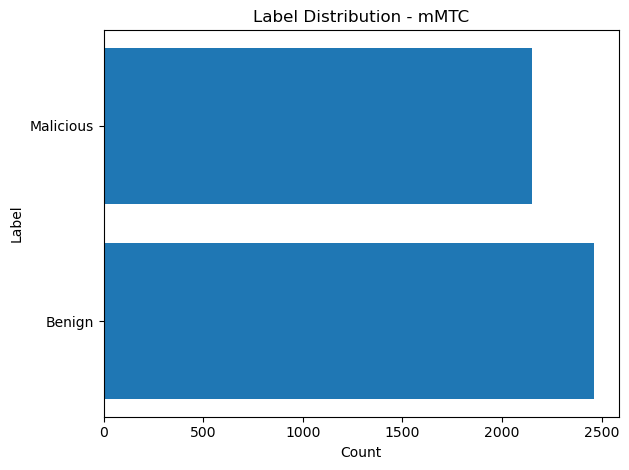

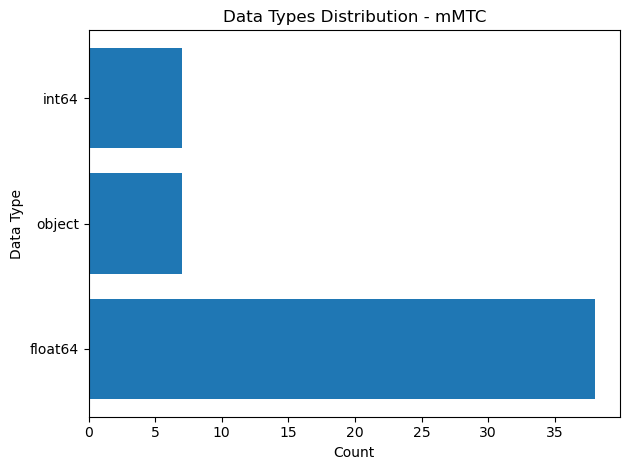


=== URLLC ===


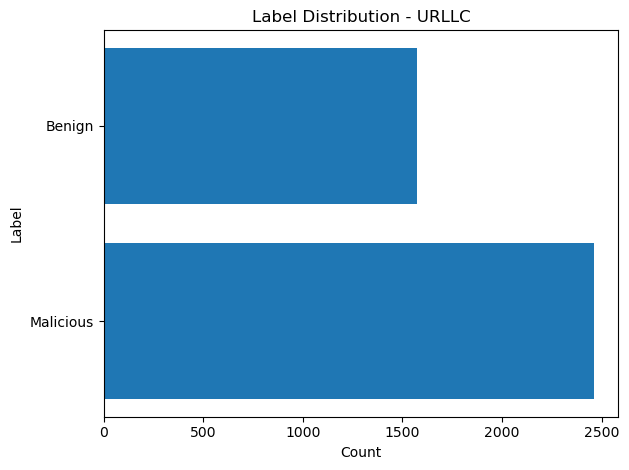

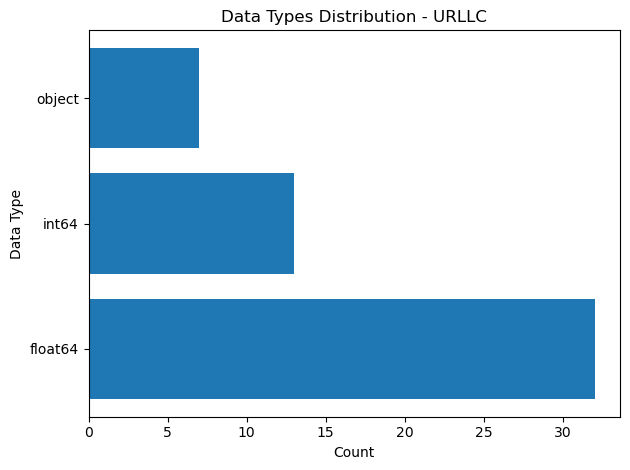


=== eMBB ===


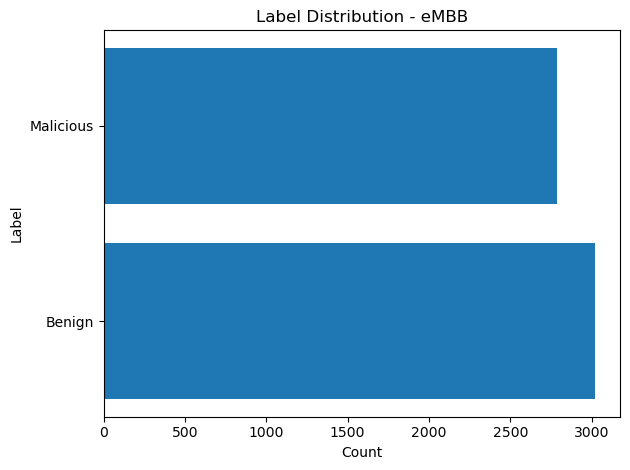

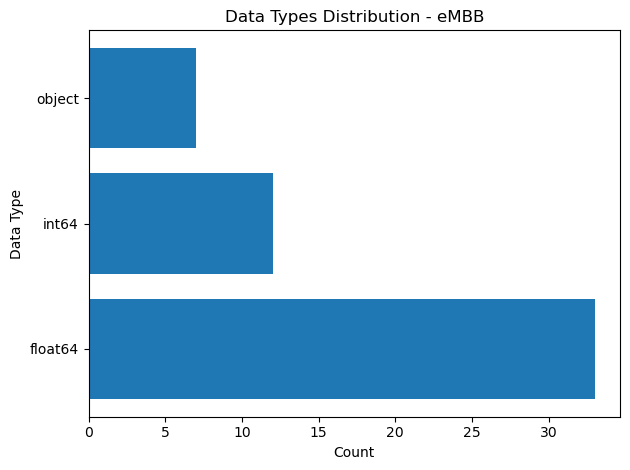


=== G6 ===


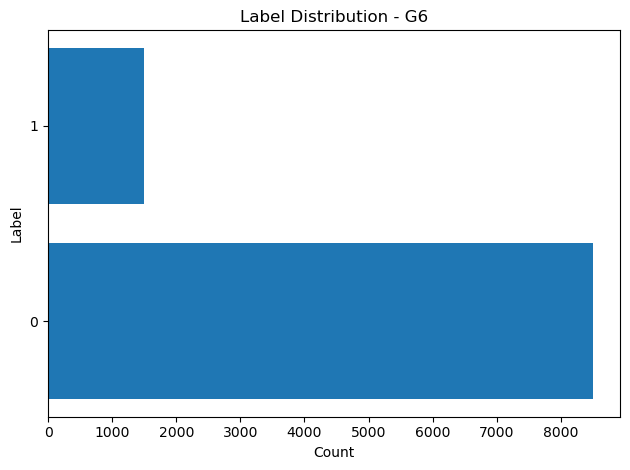

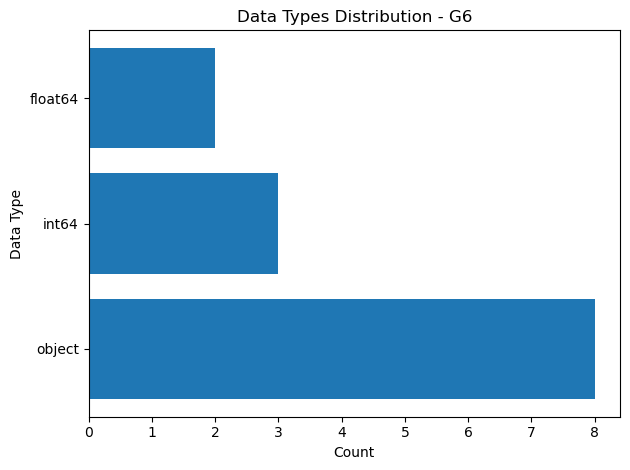

In [3]:
def dataset_overview(df, name, label_col="Label"):
    print(f"\n=== {name} ===")

    if label_col not in df.columns:
        print(f"  Warning: '{label_col}' column not found. Available: {list(df.columns)}")
        return

    label_counts = df[label_col].value_counts(dropna=False)

    plt.figure()
    plt.barh(label_counts.index.astype(str), label_counts.values)
    plt.title(f"Label Distribution - {name}")
    plt.xlabel("Count")
    plt.ylabel("Label")
    plt.tight_layout()
    plt.show()

    dtype_counts = df.dtypes.value_counts()
    plt.figure()
    plt.barh(dtype_counts.index.astype(str), dtype_counts.values)
    plt.title(f"Data Types Distribution - {name}")
    plt.xlabel("Count")
    plt.ylabel("Data Type")
    plt.tight_layout()
    plt.show()


for n, d in datasets.items():
    dataset_overview(d, n, label_col="Label")


# 📌 Data Quality Report

## 4. Data Quality Assessment

This section evaluates:

- Missing values  
- Duplicate rows  
- Outliers (IQR-based detection)  

Understanding data quality is essential before training machine learning models to avoid biased or misleading results.


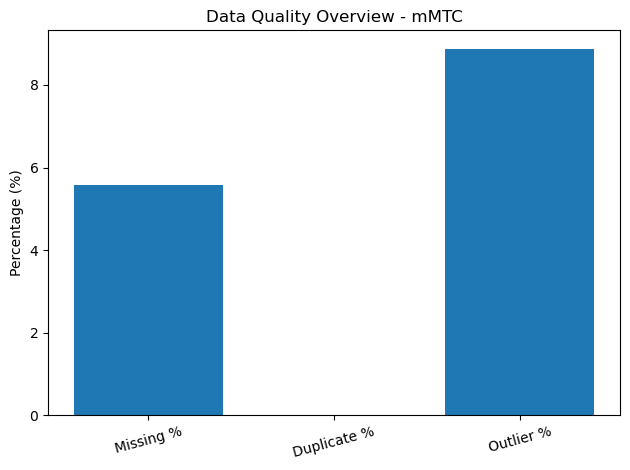

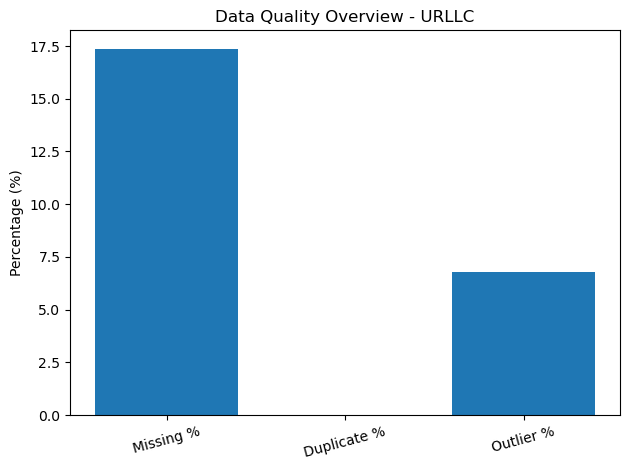

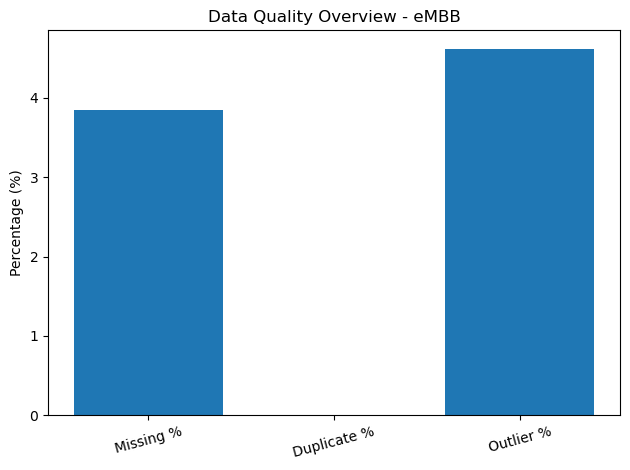

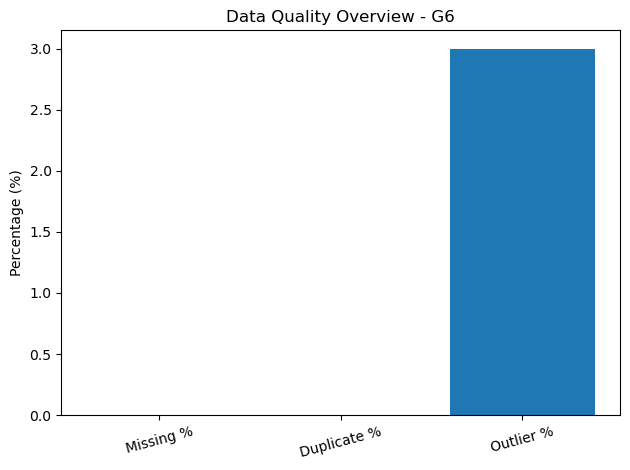

In [4]:
def quality_report_graph(df, name):
    total_rows = len(df)

    missing_percent   = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    duplicate_percent = (df.duplicated().sum() / total_rows) * 100

    numeric_cols  = df.select_dtypes(include=np.number).columns
    outlier_total = 0
    for col in numeric_cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR    = Q3 - Q1
        outlier_total += ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    outlier_percent = (outlier_total / (total_rows * len(numeric_cols))) * 100 if len(numeric_cols) > 0 else 0

    metrics = ["Missing %", "Duplicate %", "Outlier %"]
    values  = [missing_percent, duplicate_percent, outlier_percent]

    plt.figure()
    plt.bar(metrics, values)
    plt.title(f"Data Quality Overview - {name}")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    quality_report_graph(d, n)


# 📌 Exploratory Data Analysis (EDA)

EDA is performed to understand the structure, distribution, and characteristics of each dataset before model training.

## 5.1 Class Distribution per Dataset


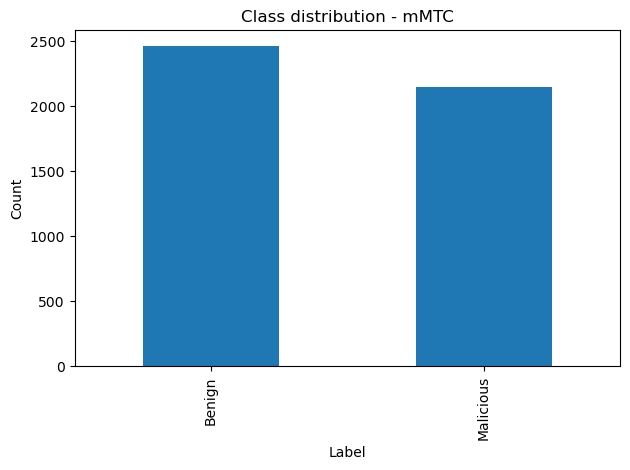

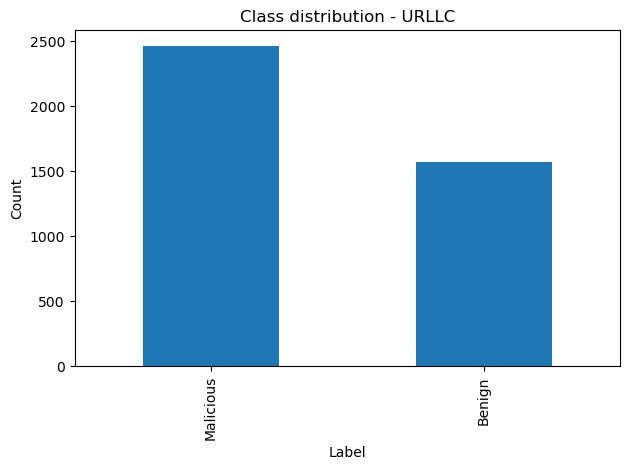

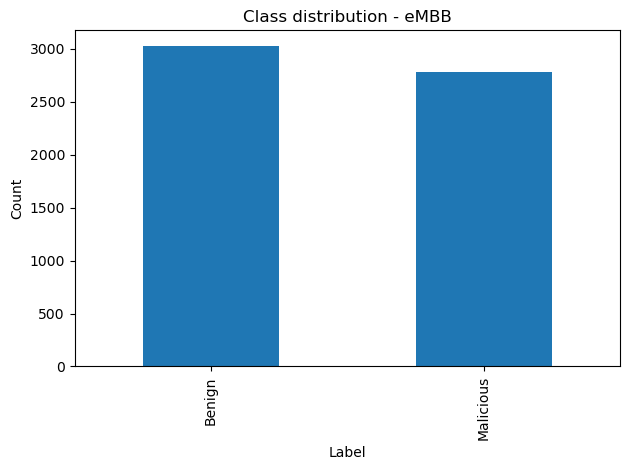

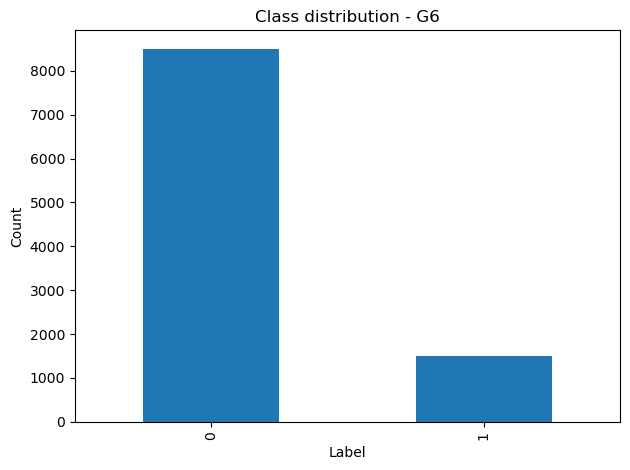

In [5]:
def plot_class_distribution(df, name, label_col="Label"):
    if label_col not in df.columns:
        print(f"Column '{label_col}' not found in {name}")
        return
    vc = df[label_col].value_counts()
    ax = vc.plot(kind="bar")
    ax.set_title(f"Class distribution - {name}")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_class_distribution(d, n, label_col="Label")


## 5.2 Numeric Feature Distribution Analysis


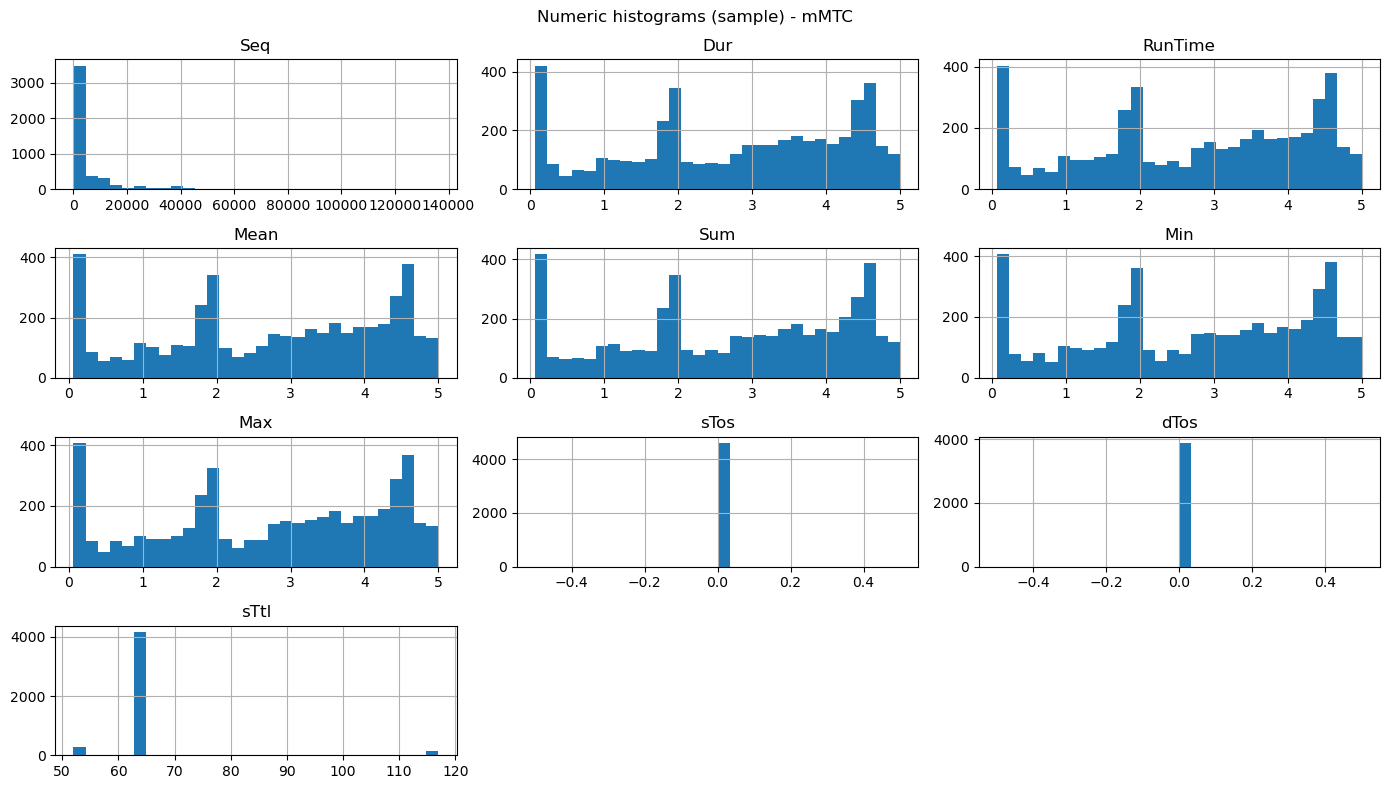

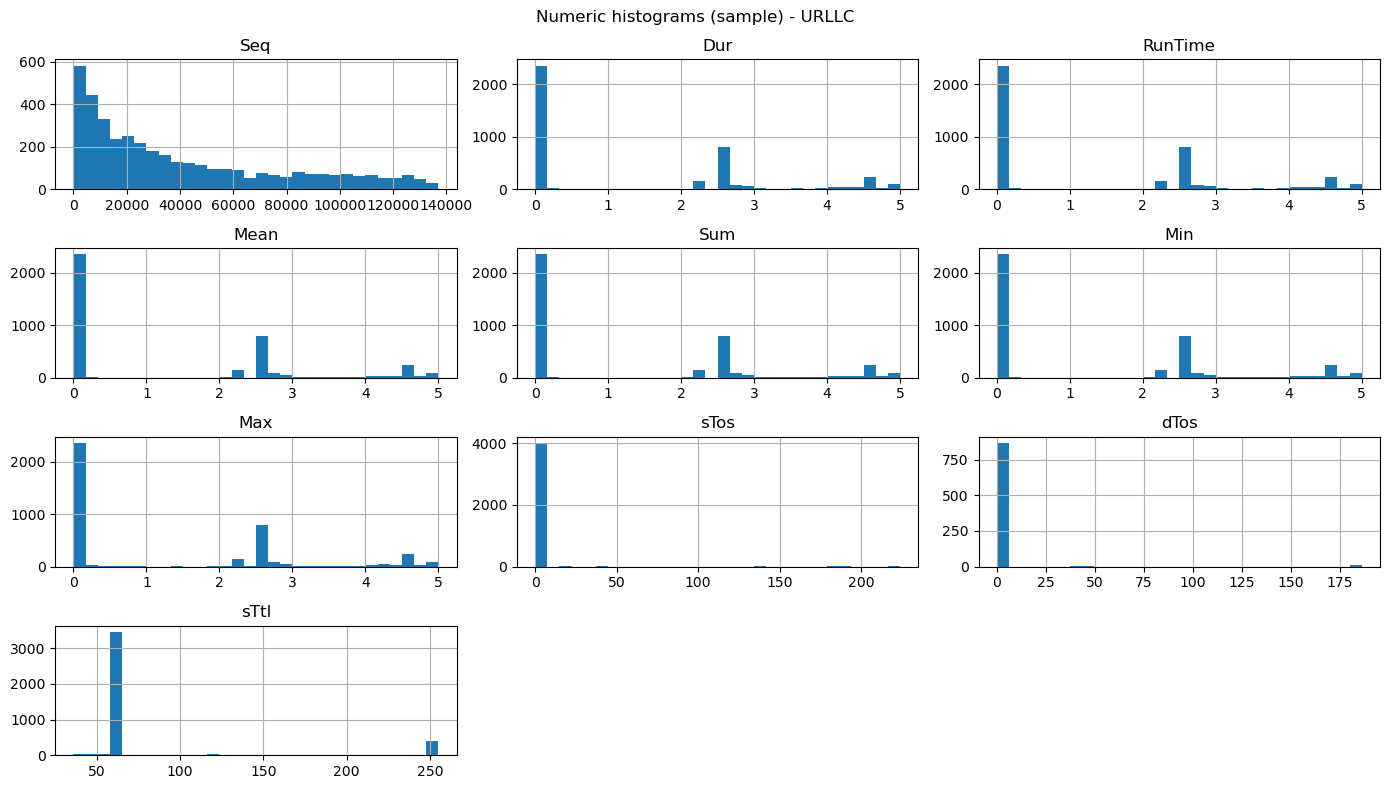

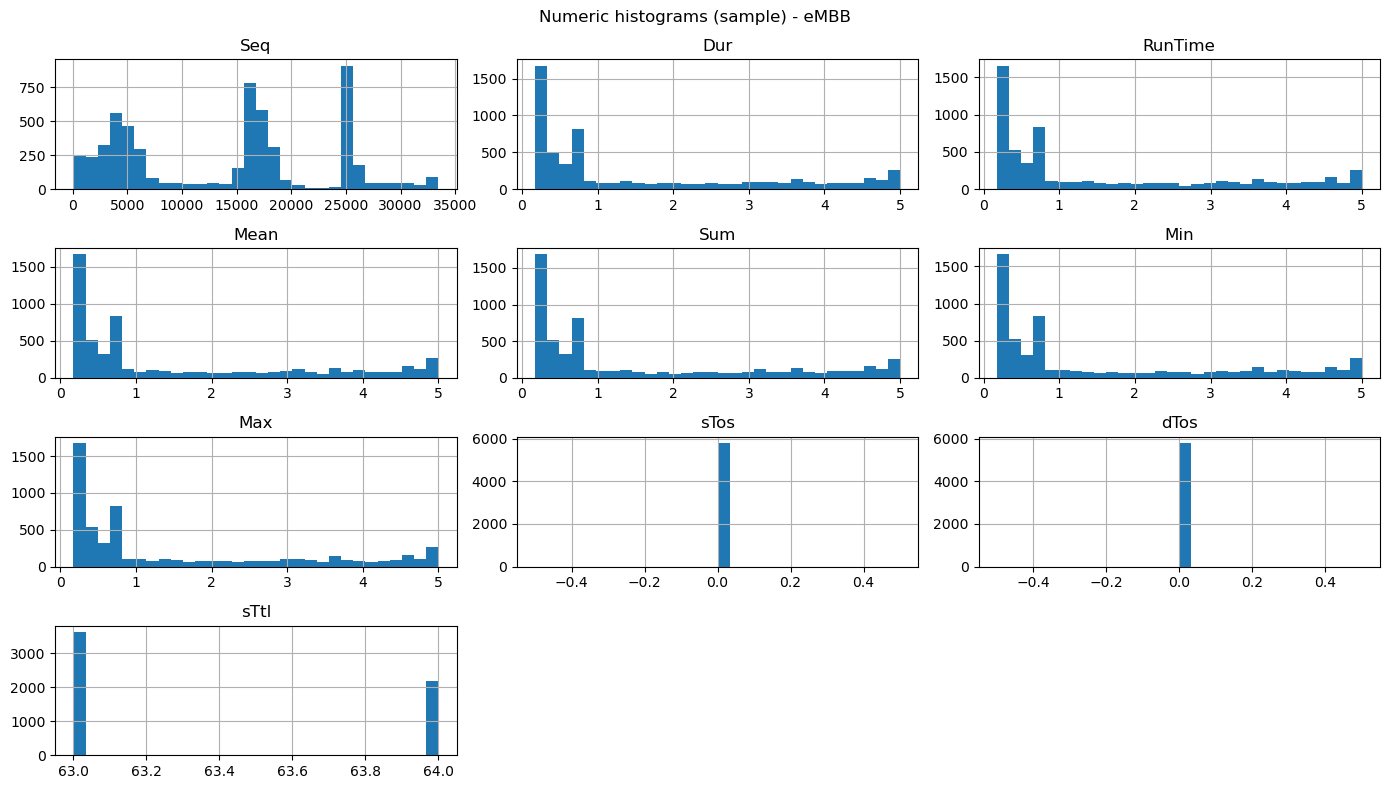

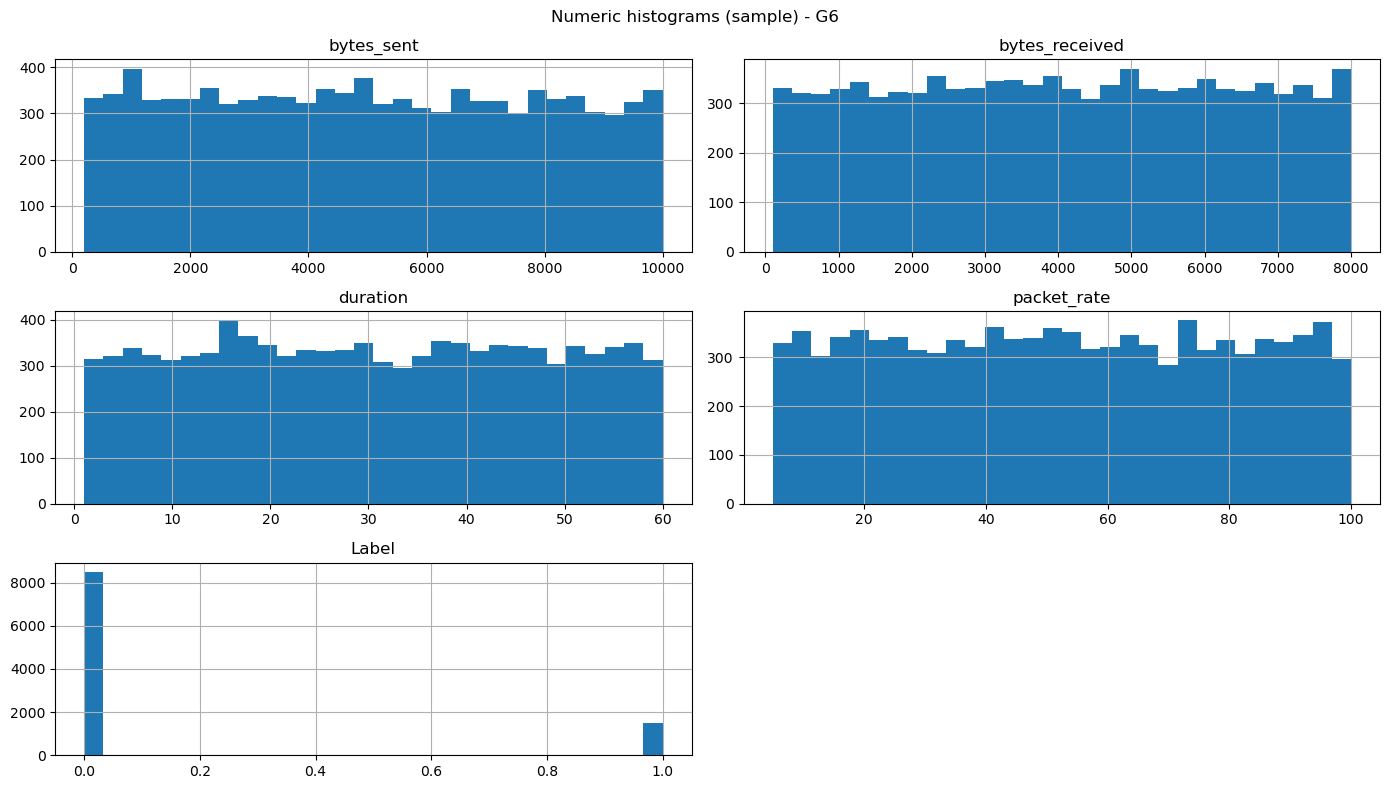

In [6]:
def plot_numeric_hists(df, name, n_cols=10):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in ["UniqueID", "X"]:
        if col in num_cols:
            num_cols.remove(col)
    sample = num_cols[:n_cols]
    if not sample:
        print(f"No numeric columns found for {name}")
        return
    df[sample].hist(bins=30, figsize=(14, 8))
    plt.suptitle(f"Numeric histograms (sample) - {name}")
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_numeric_hists(d, n, n_cols=10)


## 5.3 Correlation Analysis Between Numeric Features


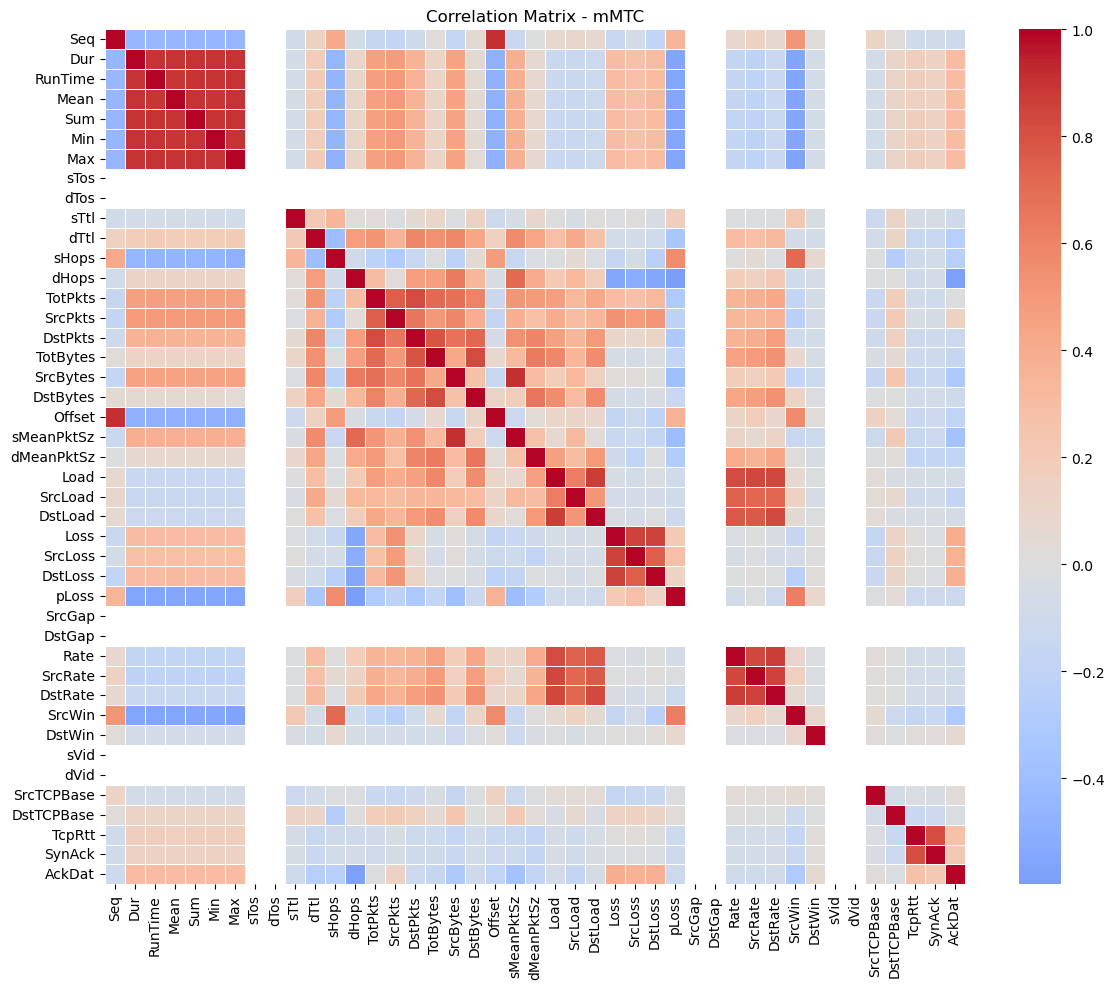

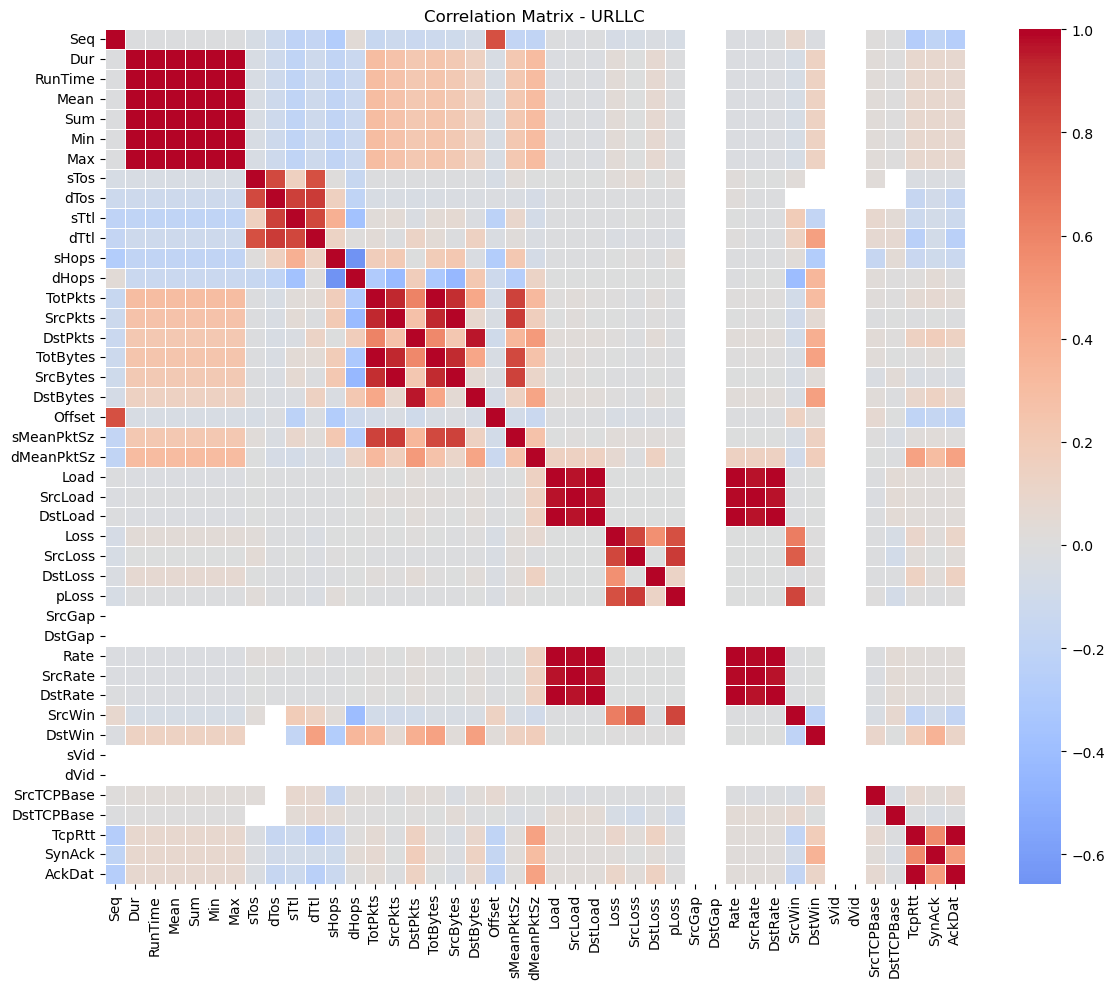

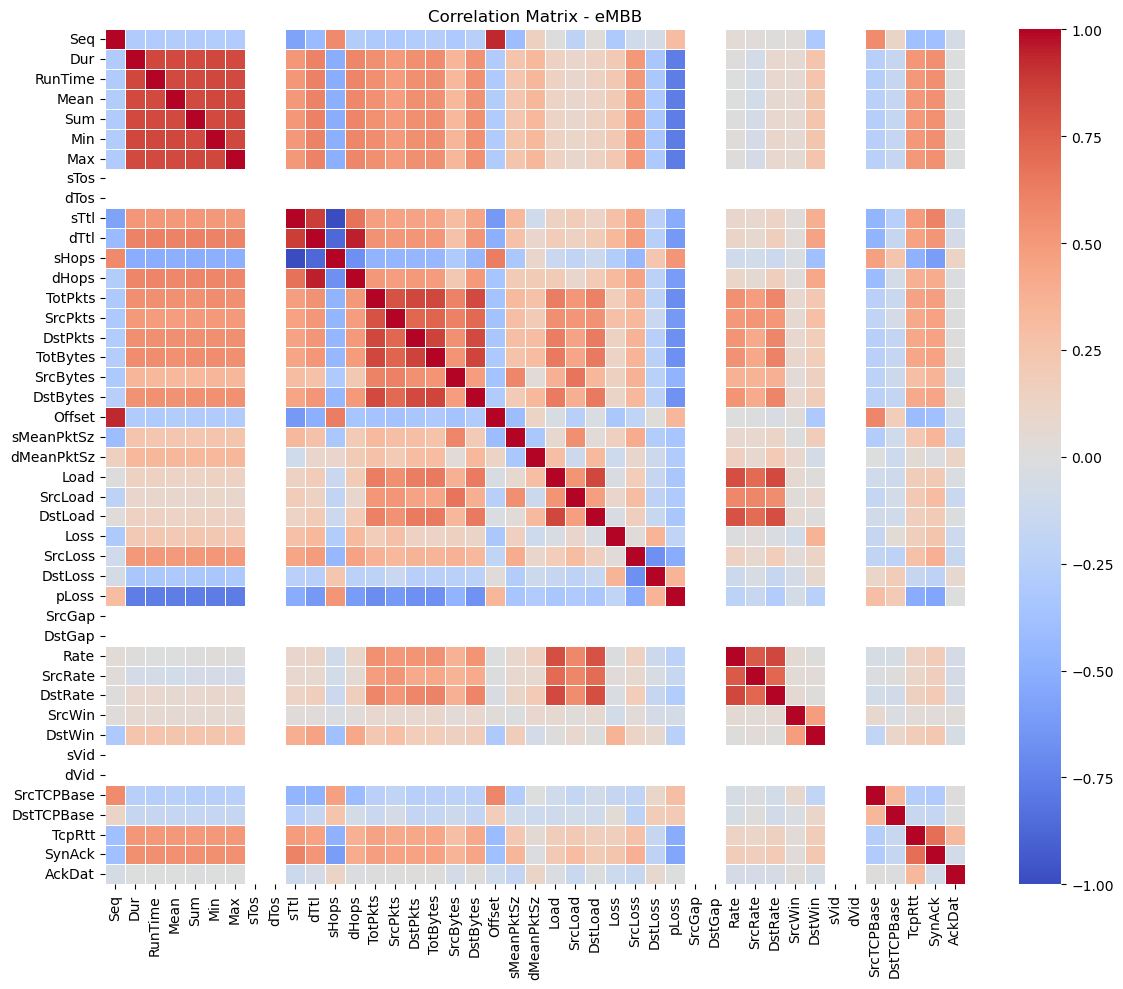

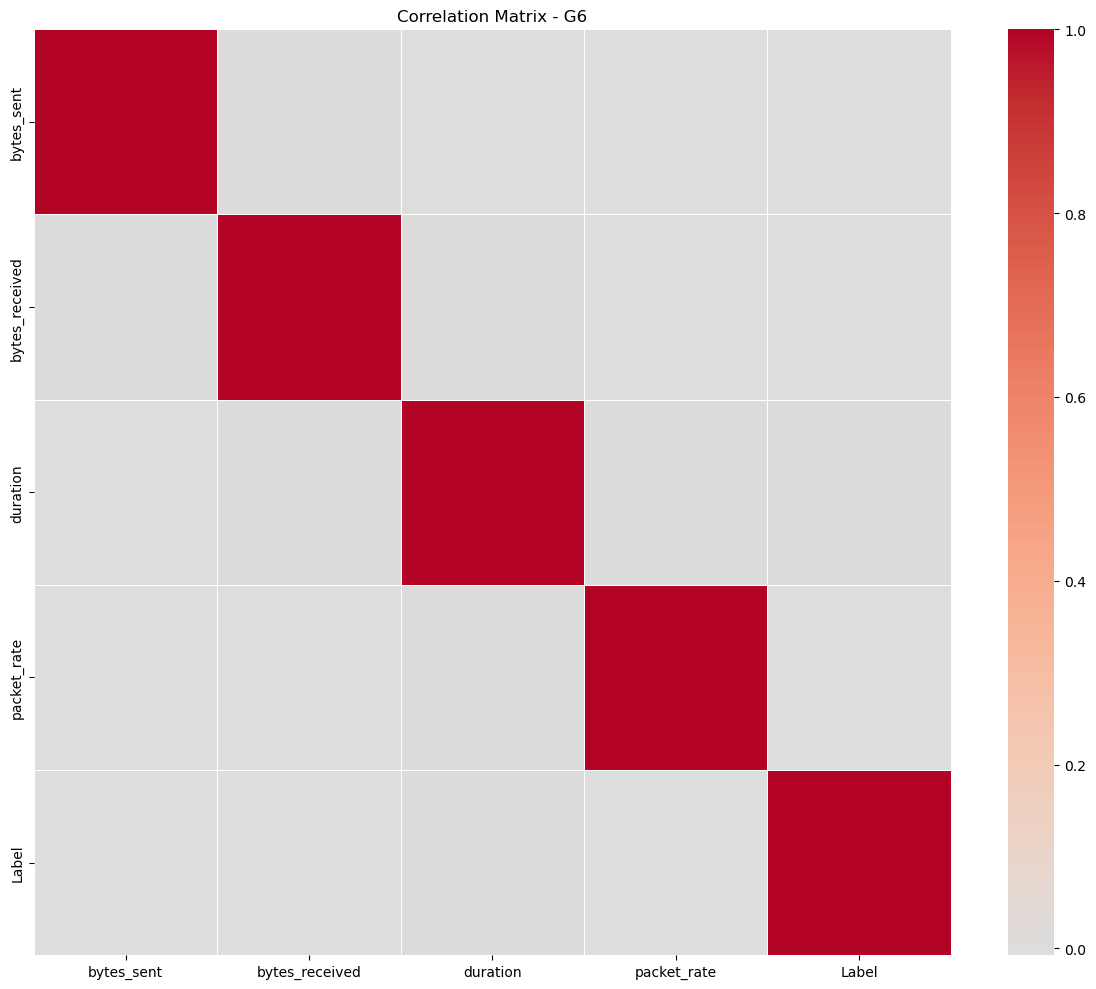

In [7]:
def plot_correlation_matrix(df, name):
    num = df.select_dtypes(include=[np.number]).copy()
    for col in ["UniqueID", "X"]:
        if col in num.columns:
            num = num.drop(columns=[col])
    if num.shape[1] < 2:
        print(f"Not enough numeric columns in {name}")
        return
    corr = num.corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
    plt.title(f"Correlation Matrix - {name}")
    plt.tight_layout()
    plt.show()

for n, d in datasets.items():
    plot_correlation_matrix(d, n)


## Data Preparation — Preprocessing Helpers

Per the Feature Justification Report (Section 5), each feature group needs a **tailored** preprocessing strategy:

| Feature Group | Transformation | Scaler |
|---|---|---|
| Volume (TotBytes, SrcBytes, DstBytes, TotPkts) | Median imputation | RobustScaler |
| Rate & Load (Rate, Load, SrcRate…) | log1p | StandardScaler |
| Timing (Dur, SrcGap, DstGap) | log1p | StandardScaler |
| Loss & Reliability (Loss, pLoss) | None | StandardScaler |
| Latency URLLC (TcpRtt, SynAck, AckDat) | None | RobustScaler |
| Latency eMBB/mMTC (TcpRtt, SynAck, AckDat) | None | StandardScaler |
| Categorical | Most-frequent imputation | OneHotEncoder |

The helper below builds a `ColumnTransformer` that applies these rules per dataset.


In [8]:
log1p_transformer = FunctionTransformer(np.log1p, validate=False)


def drop_all_missing_columns(X):
    return X.loc[:, X.isna().mean() < 1.0]


def make_xy(df, label_col="Label"):
    drop_cols = [label_col, "predicted", "UniqueID", "X",
                 "anomaly_type", "Label",
                 "SrcAddr", "DstAddr", "Sport", "Dport",
                 "source_ip", "destination_ip", "timestamp"]
    drop_cols = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=drop_cols, errors="ignore")
    X = drop_all_missing_columns(X)
    y = df[label_col]
    return X, y


def build_preprocessor(X, dataset_name="generic"):
    """
    Build a ColumnTransformer following the report's Section 5 strategy.
    Applies RobustScaler for volume/latency-critical features,
    log1p + StandardScaler for rate/timing features.
    """
    VOLUME_COLS  = ["TotBytes", "SrcBytes", "DstBytes", "TotPkts",
                    "bytes_sent", "bytes_received"]
    RATE_COLS    = ["Rate", "SrcRate", "DstRate", "Load", "SrcLoad", "DstLoad",
                    "packet_rate"]
    TIMING_COLS  = ["Dur", "SrcGap", "DstGap", "duration"]
    LOSS_COLS    = ["Loss", "pLoss"]
    LATENCY_COLS = ["TcpRtt", "SynAck", "AckDat"]
    CAT_COLS     = ["protocol", "content_type", "activity_label", "user_type"]

    present = set(X.columns.str.strip())

    vol_feats     = [c for c in VOLUME_COLS  if c in present]
    rate_feats    = [c for c in RATE_COLS    if c in present]
    timing_feats  = [c for c in TIMING_COLS  if c in present]
    loss_feats    = [c for c in LOSS_COLS    if c in present]
    latency_feats = [c for c in LATENCY_COLS if c in present]
    cat_feats     = [c for c in CAT_COLS     if c in present]

    # RobustScaler for URLLC (latency SLA critical), StandardScaler otherwise
    latency_scaler = RobustScaler() if dataset_name == "URLLC" else StandardScaler()

    transformers = []

    if vol_feats:
        transformers.append(("volume", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  RobustScaler()),
        ]), vol_feats))

    if rate_feats:
        transformers.append(("rate", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log1p",   log1p_transformer),
            ("scaler",  StandardScaler()),
        ]), rate_feats))

    if timing_feats:
        transformers.append(("timing", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log1p",   log1p_transformer),
            ("scaler",  StandardScaler()),
        ]), timing_feats))

    if loss_feats:
        transformers.append(("loss", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), loss_feats))

    if latency_feats:
        transformers.append(("latency", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  latency_scaler),
        ]), latency_feats))

    if cat_feats:
        transformers.append(("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_feats))

    if not transformers:
        raise ValueError(f"No known feature columns found in dataset '{dataset_name}'")

    return ColumnTransformer(transformers, remainder="drop")


print("Preprocessing helpers defined.")


Preprocessing helpers defined.


# eMBB

## Selected Core Features for eMBB DDoS Detection

- **Dur** -> Detects abnormal short repetitive flows or unusually persistent sessions.  
- **TotPkts** -> Primary volumetric indicator – detects packet flood behavior.
- **TotBytes** -> Measures bandwidth abuse typical of DDoS saturation.
- **Rate** -> Critical for eMBB – abnormal throughput spikes reveal attack traffic.
- **Load** -> Represents congestion level and infrastructure stress.
- **Loss / pLoss** -> Packet drop increase indicates network saturation.
- **TcpRtt** -> Elevated RTT confirms service degradation under attack.  

---

## Rationale

These features represent **behavioral anomalies** rather than:

- Protocol-based attributes  
- Identifier-based columns  
- Static routing information  

This ensures better generalization and stronger detection of volumetric attacks in high-throughput environments.


In [9]:
df_embb = datasets["eMBB"].copy()
df_embb.columns = df_embb.columns.str.strip()

embb_features = [
    "Dur",      # flow duration
    "TotPkts",  # packet flood indicator
    "TotBytes", # bandwidth saturation
    "Rate",     # throughput anomaly
    "Load",     # congestion level
    "Loss",     # packet drops
    "pLoss",    # packet loss ratio
    "TcpRtt",   # latency degradation
]
embb_features = [c for c in embb_features if c in df_embb.columns]

X_embb = df_embb[embb_features]
y_embb = df_embb["Label"]

print("Selected eMBB features:", embb_features)
print("eMBB Feature Shape:", X_embb.shape)
display(X_embb.head())


Selected eMBB features: ['Dur', 'TotPkts', 'TotBytes', 'Rate', 'Load', 'Loss', 'pLoss', 'TcpRtt']
eMBB Feature Shape: (5808, 8)


,Dur,TotPkts,TotBytes,Rate,Load,Loss,pLoss,TcpRtt
0,0.713976,21.0,3296.0,28.012146,3.339048e+04,1.0,4.545455,0.015993
1,0.233904,17.0,7435.0,68.404129,2.198851e+05,1.0,5.555556,0.069788
2,0.248047,18.0,5960.0,68.535400,1.690970e+05,1.0,5.263158,0.017124
3,2.971093,744.0,876117.0,250.076324,2.354840e+06,1.0,0.134228,0.044884
4,1.422108,360.0,269266.0,252.442139,1.506372e+06,1.0,0.277008,0.034968


# 📌 mMTC Feature Selection

## Description

Key behavioral features for the **mMTC (Massive Machine Type Communications)** dataset.

## ✅ Selected Features (per report)

- **TotPkts** → Most powerful single discriminator; SYN Scan < 10 pkts in 80.3% of RST flows  
- **Rate** → IoT botnet burst detection (spikes above 0.1–2 pps baseline)  
- **SrcGap / DstGap** → Uniquely valuable in mMTC; IoT devices transmit at regular intervals  
- **Dur** → Attack 2 median 3.47s (Slow Exhaustion) vs short SYN Scans  
- **Load** → Attack 2 uses only 2,338 bps — deliberately low; low Load + long Dur = slow attack  
- **Loss** → Resource exhaustion on IoT device side when connection tables fill  
- **TcpRtt** → 30.2% of Attack 2 flows have TcpRtt > 50ms; normal IoT RTT well below 50ms  

## ❌ Excluded Features (per report)

SrcAddr/DstAddr/Sport/Dport (overfitting/spoofing), Proto,  
sTtl/dTtl (lab artefact — 94% share sTtl=63),  
**SynAck/AckDat** (irrelevant for Slow Exhaustion & FIN Scan attacks),  
**TotBytes/SrcBytes/DstBytes** (attacks indistinguishable from benign on volume alone),  
SrcJitter/DstJitter, SIntPkt/DIntPkt, pLoss/SrcLoss/DstLoss (minimal in slow-rate attacks)


In [10]:
# FIXED: Removed TotBytes/SrcBytes/DstBytes (volume insufficient vs slow attacks),
#         Removed SynAck/AckDat (irrelevant for Slow Exhaustion & FIN Scan),
#         Removed pLoss/SrcLoss/DstLoss (minimal signal in slow-rate attacks)

df_mmtc = datasets["mMTC"].copy()
df_mmtc.columns = df_mmtc.columns.str.strip()

mmtc_features = [
    "TotPkts",  # most powerful discriminator; SYN Scan < 10 pkts in 80.3% of RST flows
    "Rate",     # IoT botnet bursts spike above periodic baseline
    "SrcGap",   # irregular gap patterns expose attack traffic (IoT transmits periodically)
    "DstGap",   # too-uniform (bot sync) or erratic (slow exhaustion) gaps
    "Dur",      # Attack 2 median 3.47s; Attack 1 very short — cleanly separates all types
    "Load",     # Attack 2 = 2,338 bps; low Load + long Dur = slow exhaustion signature
    "Loss",     # device-side congestion when connection tables fill
    "TcpRtt",   # 30.2% of Attack 2 flows > 50ms; reliable slow-attack indicator
]
mmtc_features = [c for c in mmtc_features if c in df_mmtc.columns]

X_mmtc = df_mmtc[mmtc_features]
y_mmtc = df_mmtc["Label"]

print("Selected mMTC features:", mmtc_features)
print("mMTC Feature Shape:", X_mmtc.shape)
display(X_mmtc.head())


Selected mMTC features: ['TotPkts', 'Rate', 'SrcGap', 'DstGap', 'Dur', 'Load', 'Loss', 'TcpRtt']
mMTC Feature Shape: (4615, 8)


,TotPkts,Rate,SrcGap,DstGap,Dur,Load,Loss,TcpRtt
0,36.0,7.413729,0,0,4.720971,6293.620605,12.0,0.118435
1,2.0,7.243438,0,0,0.138056,4288.115234,2.0,0.000000
2,44.0,8.644797,0,0,4.974090,7723.221680,15.0,0.000000
3,12.0,9.501253,0,0,1.157742,6578.322266,1.0,0.207826
4,18.0,98.396713,0,0,0.172770,362053.625000,1.0,0.041981


# 📌 URLLC Feature Selection

## Description

Critical behavioral features for the **URLLC (Ultra-Reliable Low Latency Communications)** dataset.

## ✅ Selected Features (per report)

- **TcpRtt** → Most critical for URLLC (<1ms SLA); directly measures SLA violation  
- **SynAck / AckDat** → Attack 3 (RST Injection): SynAck = 1.84ms (anomalously fast, mid-handshake)  
- **Loss** → Early-warning signal before RTT increases become catastrophic  
- **Dur** → 48.7% of UDP DDoS flows have Dur=0 (single-packet attacks)  
- **Rate** → Separates aggressive flood (high rate) from stealthy recon (Rate=0.22 pps)  
- **TotPkts** → 48.7% of Attack 1 flows = TotPkts=1; TotPkts=2 for Slow Recon  
- **TotBytes** → Low TotBytes + TotPkts=1 + Dur=0 = precise UDP DDoS signature  

## ❌ Excluded Features (per report)

sTtl/dTtl (lab artefact — 94% share sTtl=63; actively harmful for generalisation),  
Proto, State (target leakage — captured by Dur=0 + TotPkts=1),  
SrcAddr/DstAddr/Sport/Dport (overfitting / IP randomisation),  
**Load** (Dur=0 makes Load undefined/infinity — numerical instability),  
**SrcLoss/DstLoss** (RST Injection produces zero loss — would miss most dangerous attack),  
**pLoss** (not in report's URLLC selected set),  
SrcGap/DstGap (URLLC is event-driven; gaps indistinguishable from legitimate),  
sMeanPktSz/dMeanPktSz, SIntPkt/DIntPkt (undefined when TotPkts=1), SrcJitter/DstJitter


In [11]:
# FIXED: Removed Load (Dur=0 makes Load undefined/infinity — numerical instability),
#         Removed SrcLoss/DstLoss (RST Injection = zero loss; would miss most dangerous attack),
#         Removed pLoss (not in report's URLLC selected set)

df_urllc = datasets["URLLC"].copy()
df_urllc.columns = df_urllc.columns.str.strip()

urllc_features = [
    "TcpRtt",   # most critical — directly measures <1ms URLLC SLA violation
    "SynAck",   # Attack 3 (RST Injection): SynAck = 1.84ms (mid-handshake injector)
    "AckDat",   # handshake completion anomaly
    "Loss",     # early-warning before RTT becomes catastrophic; UDP floods fill buffers
    "Dur",      # 48.7% of Attack 1 (UDP DDoS) have Dur=0; RST Injection also Dur=0
    "Rate",     # separates aggressive flood from stealthy recon (0.22 pps)
    "TotPkts",  # Attack 1 = TotPkts=1; Attack 2 = TotPkts=2; clearest DDoS signature
    "TotBytes", # low TotBytes + TotPkts=1 + Dur=0 = precise UDP DDoS flood signature
]
urllc_features = [c for c in urllc_features if c in df_urllc.columns]

X_urllc = df_urllc[urllc_features]
y_urllc = df_urllc["Label"]

print("Selected URLLC features:", urllc_features)
print("URLLC Feature Shape:", X_urllc.shape)
display(X_urllc.head())


Selected URLLC features: ['TcpRtt', 'SynAck', 'AckDat', 'Loss', 'Dur', 'Rate', 'TotPkts', 'TotBytes']
URLLC Feature Shape: (4033, 8)


,TcpRtt,SynAck,AckDat,Loss,Dur,Rate,TotPkts,TotBytes
0,0.0,0.0,0.0,0,0.000289,3460.207764,2,124
1,0.0,0.0,0.0,0,0.000000,0.000000,1,74
2,0.0,0.0,0.0,0,2.560251,0.390587,2,84
3,0.0,0.0,0.0,0,0.046014,108.662582,6,730
4,0.0,0.0,0.0,0,0.000000,0.000000,1,42


# 📌 6G Feature Selection

## Description

Features for the **6G (6G E-Learning Network Traffic)** dataset.  
Attack flows are statistically near-identical to benign on volume alone — **contextual features are essential**.

## ✅ Selected Features (per report)

- **bytes_sent / bytes_received** → Volume ratio differs by attack type  
- **duration** → Malware Injection has longest median (30.58s) — persistent covert channel  
- **packet_rate** → Most discriminative; DDoS = 52.88 pps, Spoofing = 49.85 pps  
- **protocol** → 6G uses 5 protocols; mismatches are strong Spoofing indicators  
- **content_type** → Defines expected traffic profile per session (lecture/video/chat/quiz)  
- **activity_label** → Anomalous activities detectable only with activity context  
- **user_type** → Role-based patterns; Spoofing frequently involves role mismatches  

## ❌ Excluded Features (per report)

**timestamp** (temporal overfitting), **source_ip / destination_ip** (IP overfitting; trivially spoofed),  
**anomaly_type** (target leakage — this IS the label), **Label** (target variable — never a feature)


In [12]:
# Target: Label (binary 0/1)
# Excluded: timestamp, source_ip, destination_ip (overfitting/spoofable),
#           anomaly_type & Label (target leakage / target variable)

G6_features = [
    "bytes_sent",      # volume — DDoS: higher outbound bursts
    "bytes_received",  # volume — Malware Injection: asymmetric receive patterns
    "duration",        # Malware Injection median 30.58s (covert channel persistence)
    "packet_rate",     # most discriminative: DDoS=52.88 pps, Spoofing=49.85 pps
    "protocol",        # mismatch = Spoofing (e.g. quiz via WebRTC instead of HTTPS)
    "content_type",    # per-context baseline: lecture/video/chat/quiz
    "activity_label",  # contextual fingerprint: discussion/stream/submit/login
    "user_type",       # role-based anomalies: learner exhibiting admin-level rates
]
G6_features = [c for c in G6_features if c in datasets["G6"].columns]

X_G6 = datasets["G6"][G6_features]
y_G6 = datasets["G6"]["Label"]

print("Selected G6 features:", G6_features)
print("G6 Feature Shape:", X_G6.shape)
display(X_G6.head())


Selected G6 features: ['bytes_sent', 'bytes_received', 'duration', 'packet_rate', 'protocol', 'content_type', 'activity_label', 'user_type']
G6 Feature Shape: (10000, 8)


,bytes_sent,bytes_received,duration,packet_rate,protocol,content_type,activity_label,user_type
0,1311,1583,35.82,60.65,TCP,lecture,submit_assignment,teacher
1,1987,1327,38.41,78.04,TCP,video,discussion,teacher
2,6223,5099,42.82,73.55,UDP,chat,discussion,teacher
3,2534,3375,18.46,95.06,WebRTC,chat,discussion,teacher
4,2233,1006,36.56,40.81,UDP,quiz,stream,admin


## 1️⃣ Random Forest (RF)

**What it is:**  
Ensemble model composed of multiple decision trees using the **bagging** technique.

**Why it is suitable for IDS:**  
Random Forest performs very well on **tabular network traffic features**, is robust to noise, and captures **non-linear patterns** in attack behavior.

### Parameters used
- **n_estimators = 300**  
  Number of trees in the forest. More trees generally increase stability.  
  300 is a strong default for intrusion detection.

- **max_depth = None**  
  Allows trees to grow deep enough to capture complex attack patterns.

- **class_weight = "balanced"**  
  Important for IDS because malicious traffic is usually the **minority class**.  
  This prevents the model from being biased toward benign traffic.

- **n_jobs = -1**  
  Uses all available CPU cores for faster training.

- **random_state = 42**  
  Ensures reproducible experimental results.



Dataset: mMTC
mMTC -> using 8 features
Accuracy: 0.9237435008665511
F1 Score: 0.9233373091963221

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.93      0.93       616
   Malicious       0.92      0.91      0.92       538

    accuracy                           0.92      1154
   macro avg       0.92      0.92      0.92      1154
weighted avg       0.92      0.92      0.92      1154



<Figure size 640x480 with 0 Axes>

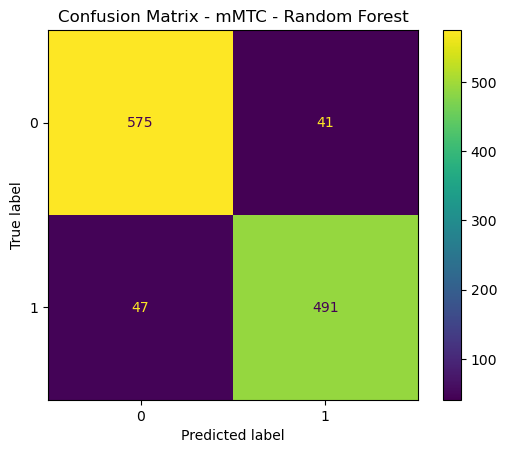


Dataset: URLLC
URLLC -> using 8 features
Accuracy: 0.6778989098116948
F1 Score: 0.6777723078253401

Classification Report:
              precision    recall  f1-score   support

      Benign       0.56      0.84      0.67       393
   Malicious       0.85      0.57      0.68       616

    accuracy                           0.68      1009
   macro avg       0.70      0.71      0.68      1009
weighted avg       0.74      0.68      0.68      1009



<Figure size 640x480 with 0 Axes>

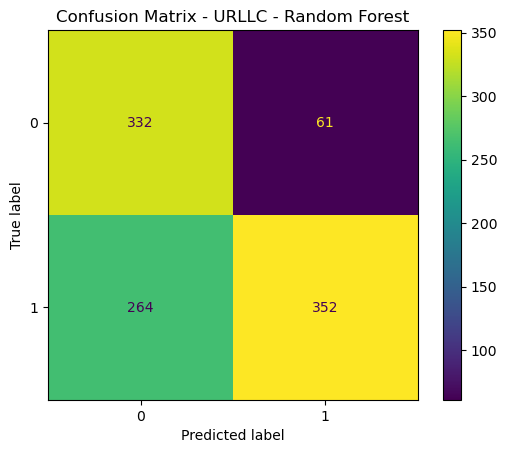


Dataset: eMBB
eMBB -> using 8 features
Accuracy: 0.9366391184573003
F1 Score: 0.9365233836708704

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94       756
   Malicious       0.94      0.93      0.93       696

    accuracy                           0.94      1452
   macro avg       0.94      0.94      0.94      1452
weighted avg       0.94      0.94      0.94      1452



<Figure size 640x480 with 0 Axes>

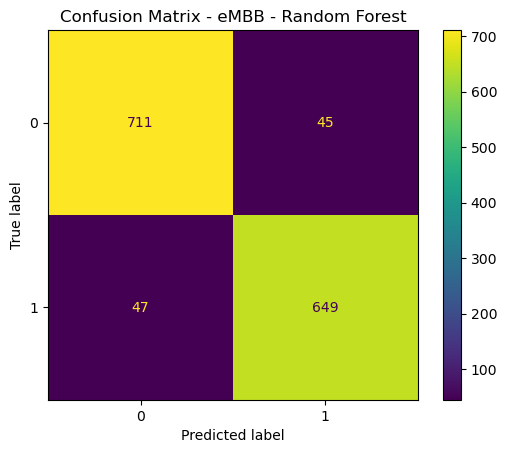


Dataset: G6
G6 -> using 8 features
Accuracy: 0.8496
F1 Score: 0.4593425605536332

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2125
           1       0.00      0.00      0.00       375

    accuracy                           0.85      2500
   macro avg       0.42      0.50      0.46      2500
weighted avg       0.72      0.85      0.78      2500



<Figure size 640x480 with 0 Axes>

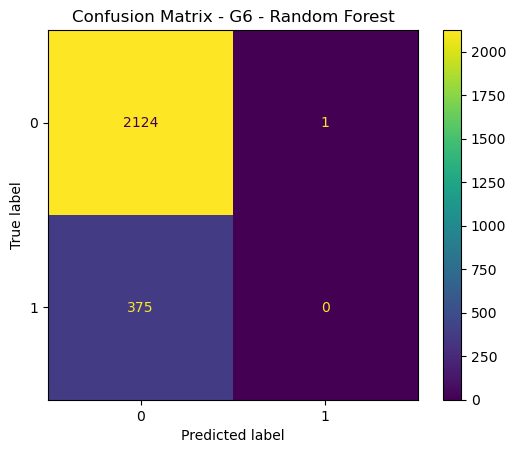

,Dataset,Accuracy,F1
2,eMBB,0.936639,0.936523
0,mMTC,0.923744,0.923337
1,URLLC,0.677899,0.677772
3,G6,0.849600,0.459343


In [13]:
FEATURE_MAP = {
    "G6":    G6_features,
    "URLLC": urllc_features,
    "mMTC":  mmtc_features,
    "eMBB":  embb_features,
}

results = []

for name, df in datasets.items():
    print(f"\n==============================")
    print(f"Dataset: {name}")
    print(f"==============================")

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]
    print(name, "-> using", len(keep), "features")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    pre   = build_preprocessor(X_train)
    model = RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42,
        n_jobs=-1, class_weight="balanced"
    )
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average="macro")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, pred))

    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure()
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {name} - Random Forest")
    plt.show()

    results.append({"Dataset": name, "Accuracy": acc, "F1": f1})

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)


## 2️⃣ XGBoost (Gradient Boosting)

**What it is:**  
An advanced **Gradient Boosted Decision Tree algorithm** where trees are built sequentially and each tree corrects the errors of the previous one.

**Why it is suitable for IDS:**  
XGBoost is widely known to achieve **state-of-the-art performance on tabular intrusion detection datasets**, as it captures complex attack patterns and feature interactions.

### Parameters used
- **n_estimators = 600**  
  Number of boosting rounds used to learn attack patterns.

- **learning_rate = 0.05**  
  Small step size that improves generalization and prevents overfitting.

- **max_depth = 6**  
  Balanced depth that captures interactions while avoiding overfitting.

- **subsample = 0.8** and **colsample_bytree = 0.8**  
  Regularization techniques that reduce overfitting.

- **scale_pos_weight = (#benign / #malicious)**  
  Handles strong **class imbalance**, which is very common in intrusion detection datasets.

- **tree_method = "hist"**  
  Faster tree construction algorithm.

- **eval_metric = "logloss"**  
  Standard evaluation metric for binary classification.

**Important:**  
XGBoost requires **numeric labels**, therefore we map:

- **Benign → 0**  
- **Malicious → 1**



Dataset: mMTC
Model: XGBoost
mMTC -> using 8 features
Accuracy: 0.9341421143847487
F1 Score: 0.9338701894076487

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       616
           1       0.93      0.93      0.93       538

    accuracy                           0.93      1154
   macro avg       0.93      0.93      0.93      1154
weighted avg       0.93      0.93      0.93      1154



<Figure size 640x480 with 0 Axes>

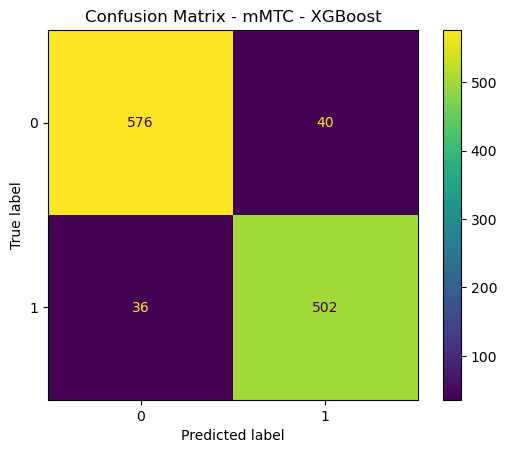


Dataset: URLLC
Model: XGBoost
URLLC -> using 8 features
Accuracy: 0.6838453914767096
F1 Score: 0.6836353271312801

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.91      0.69       393
           1       0.90      0.54      0.68       616

    accuracy                           0.68      1009
   macro avg       0.73      0.72      0.68      1009
weighted avg       0.77      0.68      0.68      1009



<Figure size 640x480 with 0 Axes>

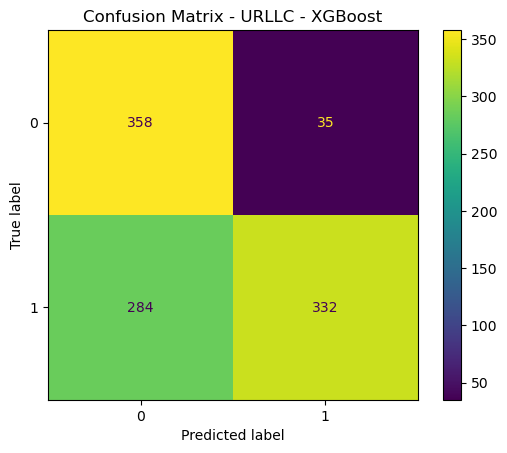


Dataset: eMBB
Model: XGBoost
eMBB -> using 8 features
Accuracy: 0.9462809917355371
F1 Score: 0.9462120060790273

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       756
           1       0.94      0.95      0.94       696

    accuracy                           0.95      1452
   macro avg       0.95      0.95      0.95      1452
weighted avg       0.95      0.95      0.95      1452



<Figure size 640x480 with 0 Axes>

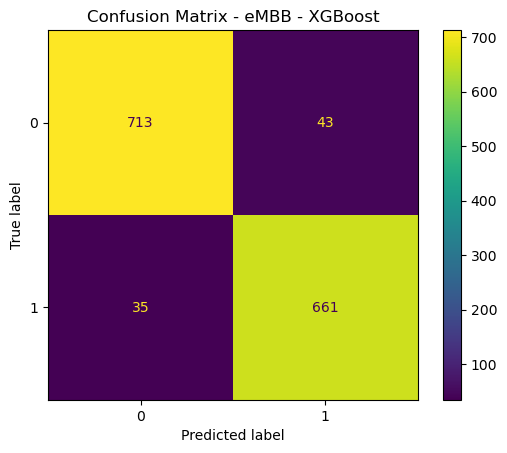


Dataset: G6
Model: XGBoost
G6 -> using 8 features
Accuracy: 0.7688
F1 Score: 0.490281124951321

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      2125
           1       0.13      0.10      0.11       375

    accuracy                           0.77      2500
   macro avg       0.49      0.49      0.49      2500
weighted avg       0.74      0.77      0.75      2500



<Figure size 640x480 with 0 Axes>

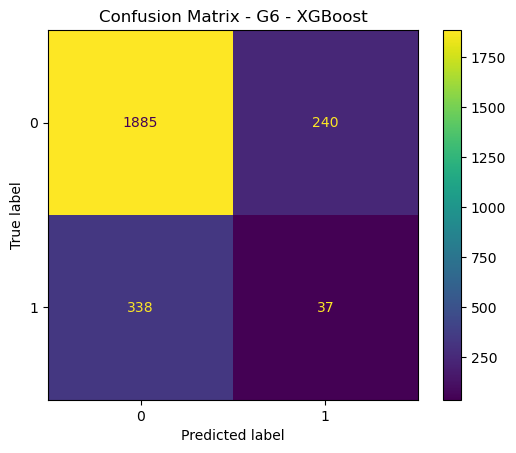

,Dataset,Accuracy,F1
2,eMBB,0.946281,0.946212
0,mMTC,0.934142,0.933870
1,URLLC,0.683845,0.683635
3,G6,0.768800,0.490281


In [14]:
results = []

for name, df in datasets.items():
    print(f"\n==============================")
    print(f"Dataset: {name}")
    print(f"Model: {'XGBoost' if USE_XGBOOST else 'HistGradientBoosting'}")
    print(f"==============================")

    X, y = make_xy(df)
    if pd.Series(y).dtype == "object":
        y = pd.Series(y).map({"Benign": 0, "Malicious": 1})

    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]
    print(name, "-> using", len(keep), "features")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    pre = build_preprocessor(X_train)

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = (neg / pos) if pos != 0 else 1.0

    if USE_XGBOOST:
        model = XGBClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            min_child_weight=1.0, gamma=0.0, tree_method="hist",
            n_jobs=-1, eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
        )
    else:
        model = HistGradientBoostingClassifier(
            max_iter=600, learning_rate=0.05, max_depth=8,
            max_leaf_nodes=31, early_stopping=True, random_state=42,
        )

    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average="macro")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, pred))

    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure()
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {name} - {'XGBoost' if USE_XGBOOST else 'HistGradientBoosting'}")
    plt.show()

    results.append({"Dataset": name, "Accuracy": acc, "F1": f1})

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)


## 3️⃣ Logistic Regression (Baseline Model)

**What it is:**  
A **linear classification model** that is simple, fast, and interpretable.

**Why it is used:**  
Logistic Regression provides a **baseline comparison**, allowing us to evaluate how much performance improves when using more complex non-linear models.

### Parameters used
- **solver = "lbfgs"**  
  Stable optimization algorithm suitable for binary classification.

- **max_iter = 20000**  
  Prevents convergence warnings during training.

- **class_weight = "balanced"**  
  Adjusts the model to handle class imbalance.

- **C = 1.0**  
  Default regularization strength used as a baseline configuration.



Dataset: mMTC
Model: Logistic Regression (Baseline)
mMTC -> using 8 features
Accuracy: 0.8812824956672444
F1 Score: 0.8811967642428546

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.85      0.88       616
   Malicious       0.84      0.92      0.88       538

    accuracy                           0.88      1154
   macro avg       0.88      0.88      0.88      1154
weighted avg       0.88      0.88      0.88      1154



<Figure size 640x480 with 0 Axes>

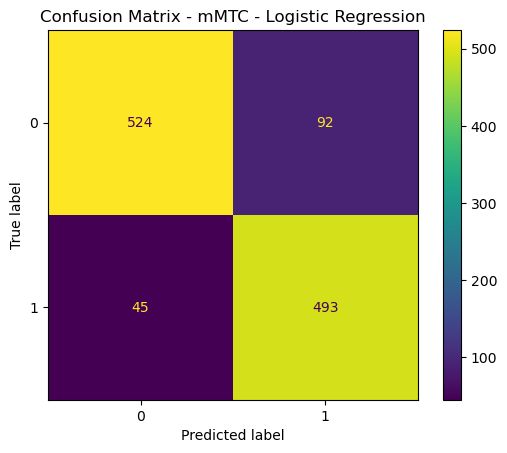


Dataset: URLLC
Model: Logistic Regression (Baseline)
URLLC -> using 8 features
Accuracy: 0.6541129831516352
F1 Score: 0.6499526333002312

Classification Report:
              precision    recall  f1-score   support

      Benign       0.54      0.70      0.61       393
   Malicious       0.77      0.62      0.69       616

    accuracy                           0.65      1009
   macro avg       0.65      0.66      0.65      1009
weighted avg       0.68      0.65      0.66      1009



<Figure size 640x480 with 0 Axes>

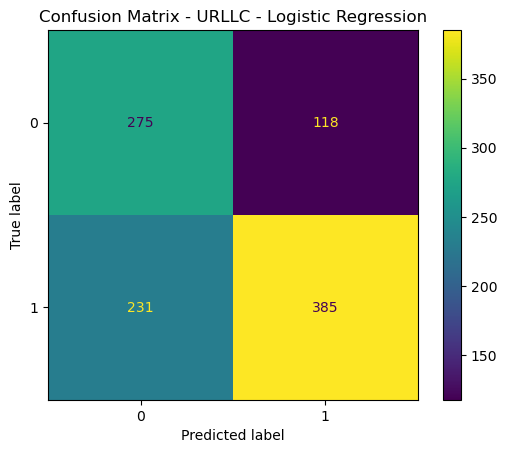


Dataset: eMBB
Model: Logistic Regression (Baseline)
eMBB -> using 8 features
Accuracy: 0.8471074380165289
F1 Score: 0.8471048272800232

Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.82      0.85       756
   Malicious       0.82      0.88      0.85       696

    accuracy                           0.85      1452
   macro avg       0.85      0.85      0.85      1452
weighted avg       0.85      0.85      0.85      1452



<Figure size 640x480 with 0 Axes>

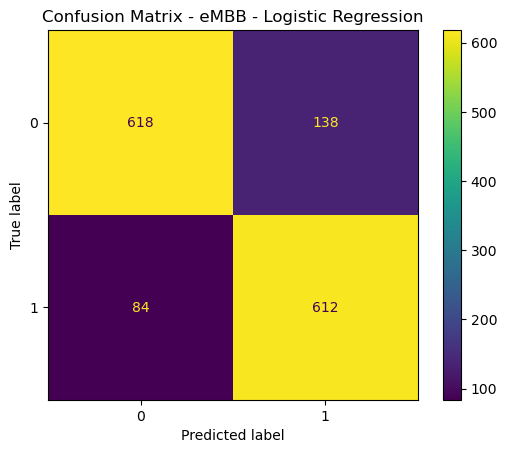


Dataset: G6
Model: Logistic Regression (Baseline)
G6 -> using 8 features
Accuracy: 0.5164
F1 Score: 0.43969412582551265

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.52      0.65      2125
           1       0.15      0.49      0.23       375

    accuracy                           0.52      2500
   macro avg       0.50      0.50      0.44      2500
weighted avg       0.75      0.52      0.58      2500



<Figure size 640x480 with 0 Axes>

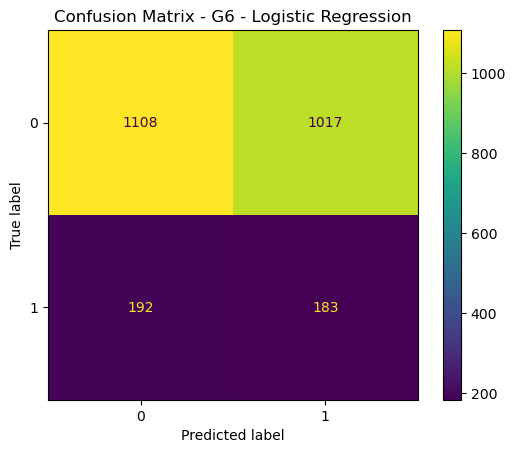

,Dataset,Accuracy,F1
0,mMTC,0.881282,0.881197
2,eMBB,0.847107,0.847105
1,URLLC,0.654113,0.649953
3,G6,0.516400,0.439694


In [15]:
results = []

for name, df in datasets.items():
    print(f"\n==============================")
    print(f"Dataset: {name}")
    print(f"Model: Logistic Regression (Baseline)")
    print(f"==============================")

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]
    print(name, "-> using", len(keep), "features")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    pre   = build_preprocessor(X_train)
    model = LogisticRegression(
        solver="lbfgs", penalty="l2", C=1.0,
        max_iter=20000, class_weight="balanced",
    )
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average="macro")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, pred))

    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure()
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {name} - Logistic Regression")
    plt.show()

    results.append({"Dataset": name, "Accuracy": acc, "F1": f1})

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)



Dataset: mMTC
RandomForest       | Acc=0.9237 | F1(macro)=0.9233


<Figure size 640x480 with 0 Axes>

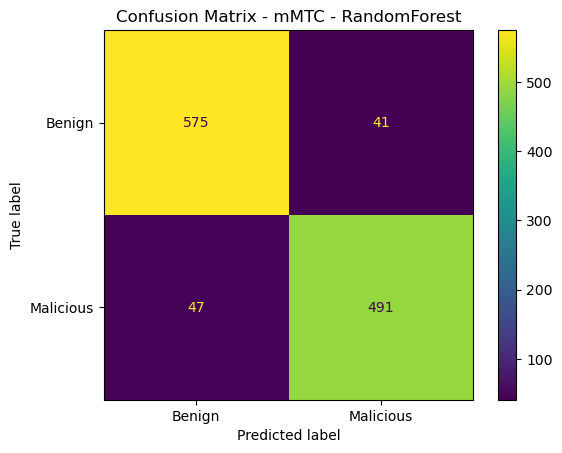

XGBoost            | Acc=0.9341 | F1(macro)=0.9339


<Figure size 640x480 with 0 Axes>

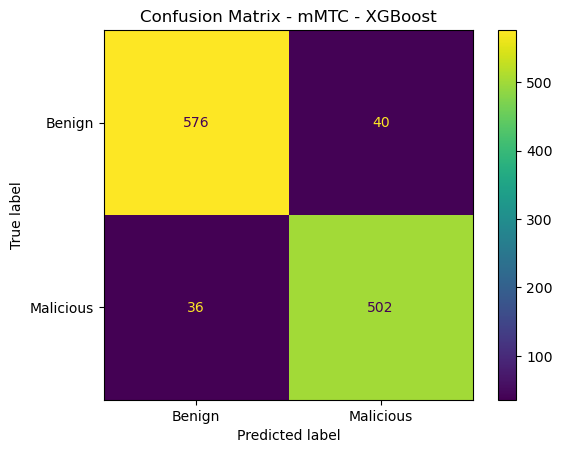

LogReg             | Acc=0.8813 | F1(macro)=0.8812


<Figure size 640x480 with 0 Axes>

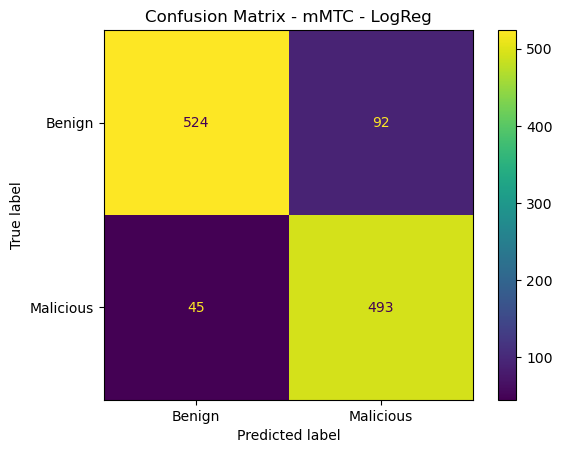


Dataset: URLLC
RandomForest       | Acc=0.6779 | F1(macro)=0.6778


<Figure size 640x480 with 0 Axes>

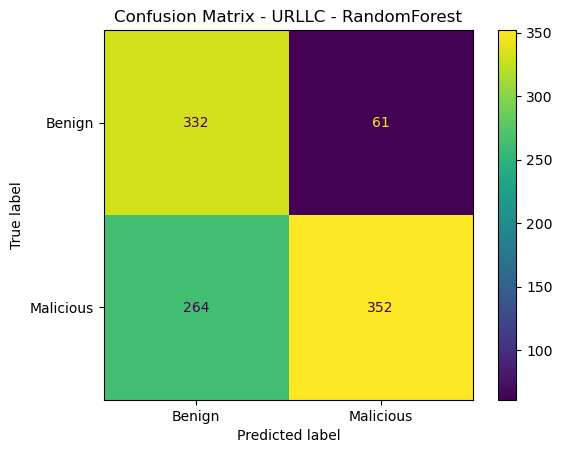

XGBoost            | Acc=0.6838 | F1(macro)=0.6836


<Figure size 640x480 with 0 Axes>

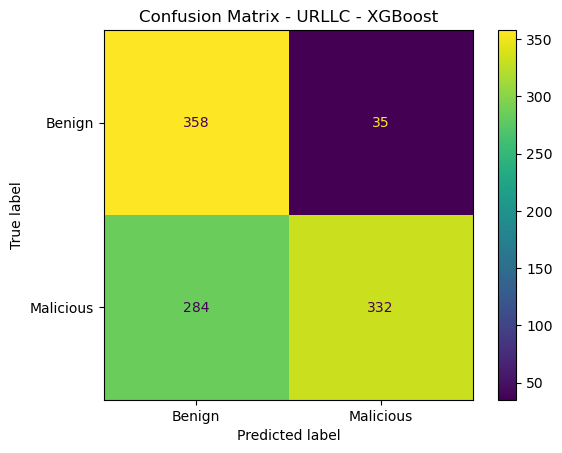

LogReg             | Acc=0.6541 | F1(macro)=0.6500


<Figure size 640x480 with 0 Axes>

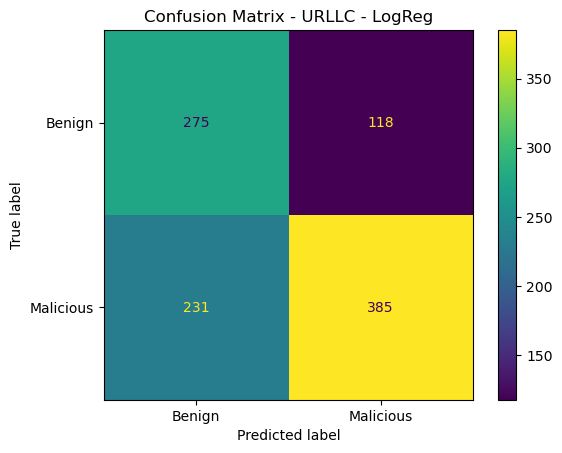


Dataset: eMBB
RandomForest       | Acc=0.9366 | F1(macro)=0.9365


<Figure size 640x480 with 0 Axes>

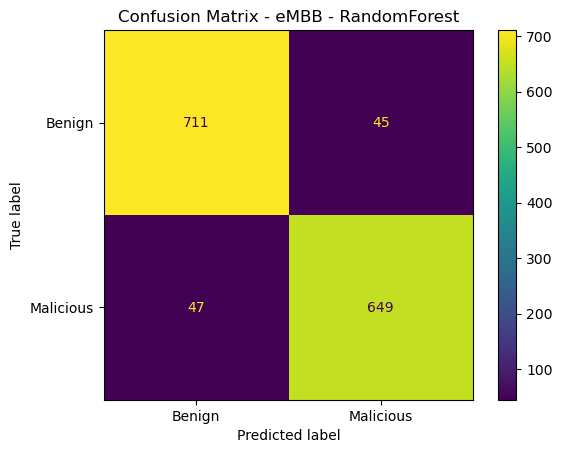

XGBoost            | Acc=0.9463 | F1(macro)=0.9462


<Figure size 640x480 with 0 Axes>

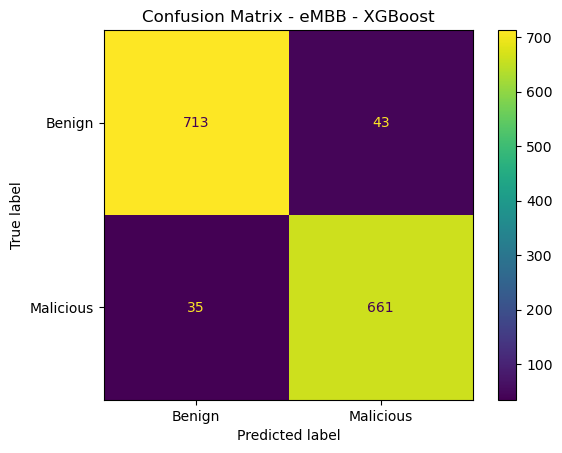

LogReg             | Acc=0.8471 | F1(macro)=0.8471


<Figure size 640x480 with 0 Axes>

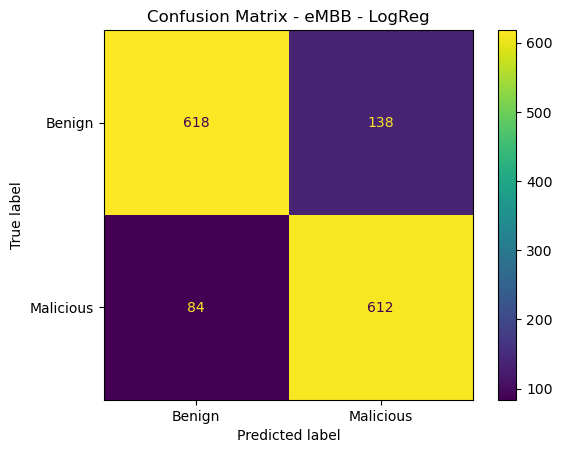


Dataset: G6
RandomForest       | Acc=0.8496 | F1(macro)=0.4593


<Figure size 640x480 with 0 Axes>

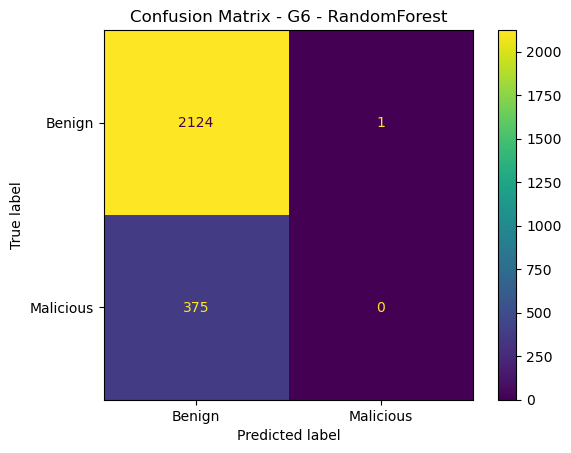

XGBoost            | Acc=0.7688 | F1(macro)=0.4903


<Figure size 640x480 with 0 Axes>

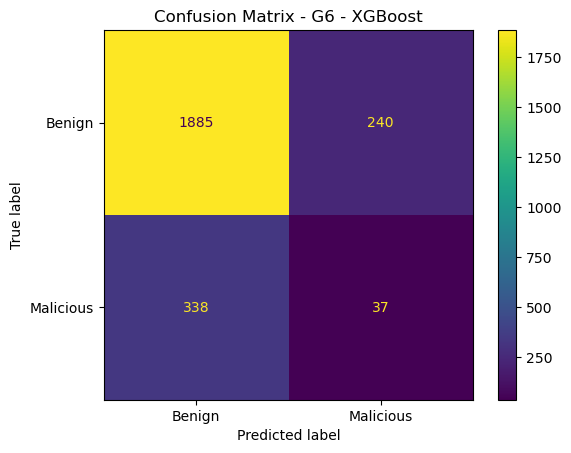

LogReg             | Acc=0.5164 | F1(macro)=0.4397


<Figure size 640x480 with 0 Axes>

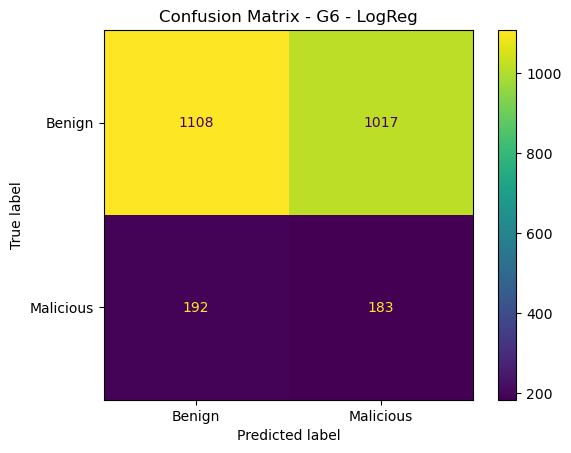

,Dataset,Model,Accuracy,F1_macro,NumFeatures
10,G6,XGBoost,0.768800,0.490281,8
9,G6,RandomForest,0.849600,0.459343,8
11,G6,LogReg,0.516400,0.439694,8
4,URLLC,XGBoost,0.683845,0.683635,8
3,URLLC,RandomForest,0.677899,0.677772,8
5,URLLC,LogReg,0.654113,0.649953,8
7,eMBB,XGBoost,0.946281,0.946212,8
6,eMBB,RandomForest,0.936639,0.936523,8
8,eMBB,LogReg,0.847107,0.847105,8
1,mMTC,XGBoost,0.934142,0.933870,8


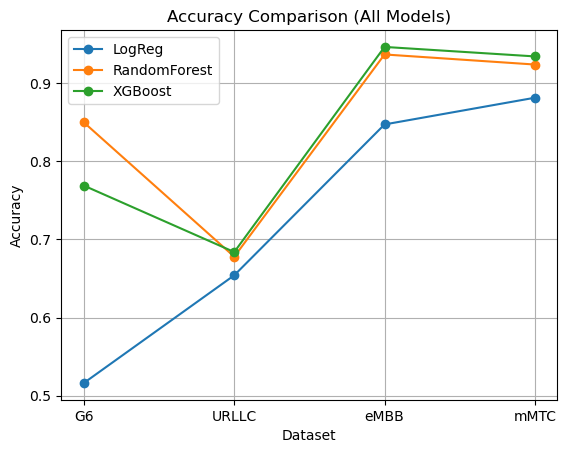

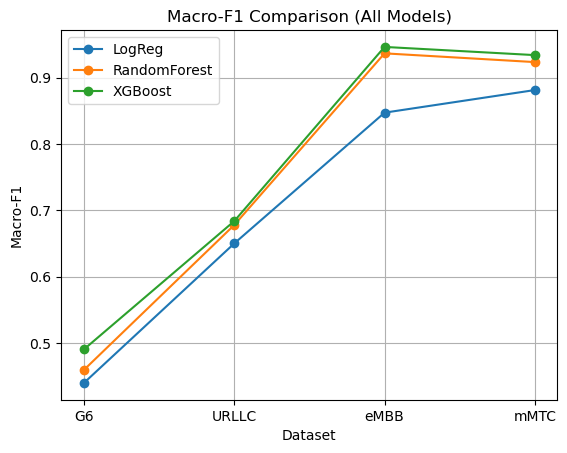

,Accuracy,F1_macro
Model,,
XGBoost,0.833267,0.763500
RandomForest,0.846970,0.749244
LogReg,0.724726,0.704487


In [16]:
def make_models(scale_pos_weight=1.0):
    models = {}

    models["RandomForest"] = RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42,
        n_jobs=-1, class_weight="balanced",
    )

    if USE_XGBOOST:
        models["XGBoost"] = XGBClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            min_child_weight=1.0, gamma=0.0, tree_method="hist",
            n_jobs=-1, eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
        )
    else:
        models["GradBoost(sklearn)"] = HistGradientBoostingClassifier(
            max_iter=600, learning_rate=0.05, max_depth=8,
            max_leaf_nodes=31, early_stopping=True, random_state=42,
        )

    models["LogReg"] = LogisticRegression(
        solver="lbfgs", penalty="l2", C=1.0,
        max_iter=20000, class_weight="balanced",
    )

    return models


all_rows = []

for dataset_name, df in datasets.items():
    print(f"\n==============================")
    print(f"Dataset: {dataset_name}")
    print(f"==============================")

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[dataset_name] if c in X.columns]
    X = X[keep]

    y_series = pd.Series(y)
    if y_series.dtype == "object":
        y_series = y_series.map({"Benign": 0, "Malicious": 1})

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_series, test_size=0.25, random_state=42, stratify=y_series
    )

    pre = build_preprocessor(X_train)

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = (neg / pos) if pos != 0 else 1.0

    for model_name, model in make_models(scale_pos_weight).items():
        pipe = Pipeline([("pre", pre), ("model", model)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, pred)
        f1  = f1_score(y_test, pred, average="macro")
        print(f"{model_name:18s} | Acc={acc:.4f} | F1(macro)={f1:.4f}")

        cm   = confusion_matrix(y_test, pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["Benign", "Malicious"])
        plt.figure()
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix - {dataset_name} - {model_name}")
        plt.show()

        all_rows.append({
            "Dataset":     dataset_name,
            "Model":       model_name,
            "Accuracy":    acc,
            "F1_macro":    f1,
            "NumFeatures": len(keep),
        })

results_df = pd.DataFrame(all_rows)
display(results_df.sort_values(["Dataset", "F1_macro"], ascending=[True, False]))

pivot_acc = results_df.pivot_table(index="Dataset", columns="Model", values="Accuracy")
pivot_f1  = results_df.pivot_table(index="Dataset", columns="Model", values="F1_macro")

plt.figure()
for col in pivot_acc.columns:
    plt.plot(pivot_acc.index, pivot_acc[col].values, marker="o", label=col)
plt.title("Accuracy Comparison (All Models)")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for col in pivot_f1.columns:
    plt.plot(pivot_f1.index, pivot_f1[col].values, marker="o", label=col)
plt.title("Macro-F1 Comparison (All Models)")
plt.xlabel("Dataset")
plt.ylabel("Macro-F1")
plt.legend()
plt.grid(True)
plt.show()

summary_df = (results_df.groupby("Model")[["Accuracy", "F1_macro"]]
              .mean()
              .sort_values("F1_macro", ascending=False))
display(summary_df)


# 📌 Final Decision Output

## Final Output: Attack Detection & Classification

This cell implements the **final three-stage decision pipeline** for each dataset, combining binary detection with rule-based attack-type identification grounded in the Feature Justification Report.

---

### 🔁 Pipeline Stages

**Stage 1 — Binary Detection (Random Forest)**
A `RandomForestClassifier` (300 trees, `class_weight="balanced"`) is trained on each dataset's selected feature subset and predicts whether each flow is benign or malicious.

**Stage 2 — Confidence Filtering (False Alarm Gate)**
Flows predicted as malicious but with a malicious-class probability below `FINAL_THRESHOLD = 0.55` are flagged as **False Alarms** rather than confirmed attacks. This reduces noisy low-confidence positives.

**Stage 3 — Attack-Type Classification (Rule-Based)**
Confirmed malicious flows are passed to `classify_attack_type()`, which applies dataset-specific thresholds drawn directly from the statistical profiling in the Feature Justification Report:

| Dataset | Attack Types Detected |
|---|---|
| **eMBB** | TCP SYN Flood, Bandwidth Saturation |
| **mMTC** | TCP SYN Scan / Connection Flooding, Slow-Rate Resource Exhaustion, FIN Scan |
| **URLLC** | UDP DDoS Flood, UDP Slow Reconnaissance, TCP RST Injection, TCP SYN Flood, TCP Session Manipulation |
| **G6** | DDoS, Malware Injection, Spoofing |

---

### 🔍 Detection Rules Summary

**eMBB**
- **TCP SYN Flood** → `Dur < 0.5s` AND `SynAck < 5ms` AND `TotPkts < 25` (bots never complete the 3-way handshake)
- **Bandwidth Saturation** → `pLoss > 4%` (deliberate bandwidth exhaustion causing packet drops)

**mMTC**
- **Slow-Rate Resource Exhaustion** → `Dur > 3s` AND `Load < 3,000 bps` AND `TcpRtt > 50ms` (covert low-bandwidth attack)
- **TCP SYN Scan / Connection Flooding** → `TotPkts < 10` (80.3% of RST flows in the report)
- **FIN Scan** → residual category (~8 packets, stealthy port probing)

**URLLC**
- **TCP RST Injection** → `Dur ≈ 0` AND `TotPkts = 1` AND `1ms < SynAck < 5ms` (mid-handshake injector anomaly)
- **UDP DDoS Flood** → `Dur ≈ 0` AND `TotPkts = 1` AND `Rate > 1` (single-packet bursts)
- **TCP SYN Flood** → `Dur ≈ 0` AND `TotPkts = 1` (no SYN-ACK received)
- **UDP Slow Reconnaissance** → `1.5s < Dur < 3.5s` AND `TotPkts = 2` AND `Rate ≈ 0.22 pps`
- **TCP Session Manipulation** → `TotPkts > 2` AND `TcpRtt > 50ms`

**G6 (EENT)**
- **Spoofing** → protocol mismatches relative to `content_type` / `user_type` (e.g., UDP on quiz/lecture, admin login via UDP)
- **Malware Injection** → `duration > 20s` (persistent covert channel, report median: 30.58s)
- **DDoS** → elevated `packet_rate` (highest mean: 52.88 pps across attack types)

---

### 📊 Output

For each dataset the cell prints:
- A **classification report** comparing predicted labels against ground truth
- A **detected attack breakdown** table counting confirmed flows per attack type

In [21]:
FINAL_THRESHOLD = 0.55

# ── Attack-type catalogue drawn from Feature Justification Report ──────────

def classify_attack_type(name, row):
    def g(col, default=None):
        return row.get(col, default)

    # ── eMBB: TCP SYN Flood vs Bandwidth Saturation ───────────────────────
    if name == "eMBB":
        dur     = g("Dur",    1.0)
        syn_ack = g("SynAck", 1.0)
        tot_pkt = g("TotPkts", 100)
        ploss   = g("pLoss",  0.0)
        if dur < 0.5 and syn_ack < 0.005 and tot_pkt < 25:
            return "TCP SYN Flood"
        if ploss > 0.04:
            return "Bandwidth Saturation"
        return "TCP SYN Flood" if tot_pkt < 25 else "Bandwidth Saturation"

    # ── mMTC: TCP SYN Scan vs Slow-Rate Resource Exhaustion vs FIN Scan ───
    if name == "mMTC":
        dur     = g("Dur",    0.0)
        load    = g("Load",   0.0)
        rtt     = g("TcpRtt", 0.0)
        tot_pkt = g("TotPkts", 0)
        if dur > 3.0 and load < 3000 and rtt > 0.05:
            return "Slow-Rate Resource Exhaustion"
        if tot_pkt < 10:
            return "TCP SYN Scan / Connection Flooding"
        return "FIN Scan"

    # ── URLLC: 5 attack types ─────────────────────────────────────────────
    if name == "URLLC":
        dur     = g("Dur",     1.0)
        tot_pkt = g("TotPkts", 100)
        rate    = g("Rate",    0.0)
        syn_ack = g("SynAck",  0.0)
        rtt     = g("TcpRtt",  0.0)
        if dur <= 0.001 and tot_pkt == 1:
            if 0.001 < syn_ack < 0.005:
                return "TCP RST Injection"
            if rate > 1.0:
                return "UDP DDoS Flood"
            return "TCP SYN Flood"
        if 1.5 < dur < 3.5 and tot_pkt == 2 and rate < 1.0:
            return "UDP Slow Reconnaissance"
        if tot_pkt > 2 and rtt > 0.05:
            return "TCP Session Manipulation"
        return "UDP DDoS Flood"

    # ── G6 (EENT): DDoS | Malware Injection | Spoofing ───────────────────
    if name == "G6":
        duration = g("duration",      0.0)
        protocol = str(g("protocol",       "")).upper()
        content  = str(g("content_type",   "")).lower()
        user_tp  = str(g("user_type",      "")).lower()
        activity = str(g("activity_label", "")).lower()

        spoofing_signals = 0
        if protocol == "UDP" and content in ("quiz", "lecture"):
            spoofing_signals += 1
        if protocol == "WEBRTC" and content in ("quiz", "submit_assignment"):
            spoofing_signals += 1
        if user_tp == "admin" and activity == "login" and protocol == "UDP":
            spoofing_signals += 1
        if spoofing_signals >= 1:
            return "Spoofing"
        if duration > 20.0:
            return "Malware Injection"
        return "DDoS"

    return "Malicious (unknown)"


# ── Detect the benign label dynamically per dataset ────────────────────────
def get_benign_label(df):
    """Return the actual string used for benign traffic in this dataset's Label column."""
    label_col = df["Label"] if "Label" in df.columns else df["is_malicious"]
    candidates = ["Benign", "Normal", "benign", "normal", "0", 0]
    counts = label_col.value_counts()
    for c in candidates:
        if c in counts.index:
            return str(c)
    # Fall back to the majority class
    return str(counts.idxmax())


# ── Main evaluation loop ───────────────────────────────────────────────────
for name, df in datasets.items():
    if name not in FEATURE_MAP:
        continue

    print("\n==============================")
    print(f"FINAL DECISION DATASET: {name}")
    print("==============================")

    BENIGN_LABEL = get_benign_label(df)

    X, y = make_xy(df)
    keep = [c for c in FEATURE_MAP[name] if c in X.columns]
    X = X[keep]

    # Build binary labels using the detected benign string
    raw_labels = pd.Series(df["Label"].astype(str).values, index=X.index)
    y_bin = (raw_labels != BENIGN_LABEL).astype(int)   # 0=benign, 1=malicious

    # Reset to clean 0..N-1 positions
    X_reset   = X.reset_index(drop=True)
    y_reset   = y_bin.reset_index(drop=True)
    df_raw    = df.reset_index(drop=True)
    lbl_reset = raw_labels.reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X_reset, y_reset,
        test_size=0.25, random_state=42,
        stratify=y_reset if y_reset.nunique() > 1 else None,
    )
    test_positions = X_test.index.tolist()   # plain integer list — no .iloc needed

    pre = build_preprocessor(X_train)
    det_model = RandomForestClassifier(
        n_estimators=300, random_state=42,
        n_jobs=-1, class_weight="balanced",
    )
    det_pipe = Pipeline([("pre", pre), ("model", det_model)])
    det_pipe.fit(X_train, y_train)

    pred_bin  = det_pipe.predict(X_test)
    classes   = list(det_pipe.named_steps["model"].classes_)
    mal_idx   = classes.index(1) if 1 in classes else None
    proba_mal = (
        det_pipe.predict_proba(X_test)[:, mal_idx]
        if mal_idx is not None
        else np.zeros(len(X_test))
    )

    # ── Build final three-way decision: Benign / False Alarm / Attack Name ─
    final_pred   = []
    attack_names = []

    for i, (bin_pred, mal_p) in enumerate(zip(pred_bin, proba_mal)):
        if bin_pred == 0:
            final_pred.append(BENIGN_LABEL)
            attack_names.append(BENIGN_LABEL)
        elif mal_p < FINAL_THRESHOLD:
            final_pred.append("False Alarm")
            attack_names.append("False Alarm")
        else:
            raw_row = df_raw.iloc[test_positions[i]].to_dict()
            attack  = classify_attack_type(name, raw_row)
            final_pred.append(attack)
            attack_names.append(attack)

    # ── Ground-truth labels ───────────────────────────────────────────────
    # For G6: use anomaly_type column when available (has "DDoS", "Malware Injection", etc.)
    # For other datasets: Label is "Benign" / "Malicious" — we keep it as-is
    attack_type_col = "anomaly_type" if "anomaly_type" in df.columns else None
    true_labels     = lbl_reset.iloc[test_positions].values

    if attack_type_col is not None:
        # G6: replace non-benign rows with their specific anomaly_type string
        anomaly_vals = df_raw.iloc[test_positions][attack_type_col].astype(str).values
        y_true_final = np.where(true_labels == BENIGN_LABEL, BENIGN_LABEL, anomaly_vals)
    else:
        # eMBB / mMTC / URLLC: ground truth is just "Benign" vs "Malicious"
        # Align to match our predicted attack names so the report is meaningful
        y_true_final = np.where(true_labels == BENIGN_LABEL, BENIGN_LABEL, "Malicious")

    labels_report = sorted(set(y_true_final) | set(final_pred))
    print(classification_report(y_true_final, final_pred,
                                labels=labels_report, zero_division=0))

    # ── Attack breakdown summary ──────────────────────────────────────────
    detected = [a for a in attack_names if a not in (BENIGN_LABEL, "False Alarm")]
    if detected:
        print("Detected attack breakdown:")
        for atk, cnt in pd.Series(detected).value_counts().items():
            print(f"  {atk:<40s} {cnt:>5d} flows")


FINAL DECISION DATASET: mMTC
                                    precision    recall  f1-score   support

                            Benign       0.92      0.93      0.93       616
                          FIN Scan       0.00      0.00      0.00         0
                       False Alarm       0.00      0.00      0.00         0
                         Malicious       0.00      0.00      0.00       538
     Slow-Rate Resource Exhaustion       0.00      0.00      0.00         0
TCP SYN Scan / Connection Flooding       0.00      0.00      0.00         0

                          accuracy                           0.50      1154
                         macro avg       0.15      0.16      0.15      1154
                      weighted avg       0.49      0.50      0.50      1154

Detected attack breakdown:
  FIN Scan                                   220 flows
  TCP SYN Scan / Connection Flooding         198 flows
  Slow-Rate Resource Exhaustion              103 flows

FINAL DECISION